# Model Decision Tree

## 3.4. Drzewa decyzyjne (Decision Tree)

Drzewa decyzyjne należą do grupy modeli uczenia nadzorowanego, które podejmują decyzje poprzez
rekurencyjne dzielenie przestrzeni cech na coraz mniejsze podzbiory.  
Model przyjmuje postać struktury drzewa, gdzie:

- **węzły wewnętrzne (ang. internal nodes)** reprezentują test na jednej ze zmiennych,
  np. *Prob_H_b365 > 0.45?*
- **gałęzie (ang. branches)** odpowiadają wynikom testu,
- **liście (ang. leaves)** zawierają finalną predykcję modelu (np. jedną z klas: *H*, *D*, *A*).

### 3.4.1. Algorytm budowania drzewa

Budowa drzewa polega na iteracyjnym wyszukiwaniu takiego podziału danych (cecha + próg),
który **maksymalizuje czystość klas** w powstałych gałęziach.  
Najpopularniejsze funkcje oceny czystości to:

#### • Indeks Giniego

\[
Gini = 1 - \sum_{k=1}^{K} p_k^2
\]

gdzie \(p_k\) jest udziałem klasy \(k\) w danym węźle.

#### • Entropia

\[
Entropy = - \sum_{k=1}^{K} p_k \log_2 (p_k)
\]

Im niższa wartość miary, tym bardziej jednorodny węzeł (czyli lepszy podział).

### 3.4.2. Zalety drzew decyzyjnych

Drzewa decyzyjne są chętnie stosowane ze względu na:

- **brak wymogu skalowania cech**,  
- **obsługę nieliniowości** oraz interakcji pomiędzy zmiennymi,
- **intuicyjną interpretowalność** (możliwość wizualizacji struktury drzewa),
- możliwość ustalania wag klas (`class_weight='balanced'`) przy danych niezrównoważonych.

Cechy te czynią drzewa atrakcyjnym modelem bazowym przy klasyfikacji wyników sportowych,
gdzie zależności między zmiennymi mogą być bardzo nieliniowe.

### 3.4.3. Wady drzew decyzyjnych

Główną słabością drzew decyzyjnych jest **wysoka podatność na przeuczenie** (overfitting).  
Drzewo niekontrolowane (bez limitu głębokości) może praktycznie „zapamiętać” dane uczące.

Dlatego konieczne jest zastosowanie tzw. *przycinania* drzewa poprzez dobranie hiperparametrów takich jak:

- `max_depth` – maksymalna głębokość drzewa,  
- `min_samples_split` – minimalna liczba próbek do podziału węzła,  
- `min_samples_leaf` – minimalna liczba próbek w liściu,  
- `class_weight` – regulacja wpływu częstości klas.

Dobór tych parametrów odbywa się zwykle metodą wyszukiwania siatką (GridSearchCV).

### 3.4.4. Zastosowanie w analizie wyników meczów

W niniejszej pracy drzewo decyzyjne wykorzystane zostało jako model klasyfikacyjny
przewidujący rezultat meczu piłkarskiego spośród trzech klas:

- **H** – zwycięstwo gospodarzy,
- **D** – remis,
- **A** – zwycięstwo gości.

Model trenowany jest na tych samych cechach, które wykorzystano przy regresji logistycznej,
co umożliwia uczciwe porównanie jakości obu podejść — modeli liniowych i nieliniowych.
Drzewo potrafi uchwycić złożone interakcje między cechami (np. między kursami bukmacherskimi,
formą z ostatnich meczów czy różnicą jakości drużyn), co czyni je dobrym uzupełnieniem
bardziej klasycznych metod statystycznych.



Przygotowanie danych

In [344]:
# --- podstawy ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

LEAGUE = "premier_league"
# LEAGUE = "serie_a"
# LEAGUE = "la_liga"
# LEAGUE = "bundesliga"
# LEAGUE = "ligue_1"
# LEAGUE = "all_leagues"

EXPERIMENT = "decision_tree"

DATA_DIR = Path("../data/processed")

DATA_PATH = DATA_DIR / LEAGUE / f"{LEAGUE}_features.csv"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{EXPERIMENT}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("LEAGUE:", LEAGUE)
print("DATA_PATH:", DATA_PATH)
print("RESULTS_DIR:", RESULTS_DIR)

LEAGUE: premier_league
DATA_PATH: ..\data\processed\premier_league\premier_league_features.csv
RESULTS_DIR: ..\results\premier_league\decision_tree


In [345]:
def save_plot(filename, dpi=150):
    plt.savefig(
        RESULTS_DIR / filename,
        dpi=dpi,
        bbox_inches="tight"
    )

def save_df(df, filename):
    df.to_csv(
        RESULTS_DIR / filename,
        index=False
    )

def close_plot():
    plt.close()



def plot_and_save_class_distribution(
    y_true_cls,
    y_pred_cls,
    option_suffix,      # np. "A", "B", "BIN"
    filename_prefix     # np. "class_distribution"
):
    """
    y_true_cls : lista klas ["H","D","A"] lub ["0","1"] itp.
    y_pred_cls : lista klas
    """

    # --- liczniki ---
    df_counts = (
        pd.DataFrame({
            "True": y_true_cls,
            "Pred": y_pred_cls
        })
        .melt(var_name="Type", value_name="Class")
        .value_counts()
        .reset_index(name="Count")
    )

    # rozbijamy na true / pred
    df_true = df_counts[df_counts["Type"] == "True"][["Class","Count"]] \
        .rename(columns={"Count":"True_Count"})
    df_pred = df_counts[df_counts["Type"] == "Pred"][["Class","Count"]] \
        .rename(columns={"Count":"Pred_Count"})

    df_final = (
        pd.merge(df_true, df_pred, on="Class", how="outer")
        .fillna(0)
        .sort_values("Class")
    )

    # --- zapis CSV ---
    save_df(
        df_final,
        f"{filename_prefix}_{option_suffix}.csv"
    )

    # --- wykres ---
    x = np.arange(len(df_final))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, df_final["True_Count"], width, label="True")
    plt.bar(x + width/2, df_final["Pred_Count"], width, label="Pred")

    plt.xticks(x, df_final["Class"])
    plt.ylabel("Liczba meczów")
    plt.title(f"Rozkład klas — Opcja {option_suffix}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    save_plot(f"{filename_prefix}_{option_suffix}.png")
    plt.show()
    close_plot()

    return df_final

In [346]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)
print(df.shape)
df.head(3)

(3420, 113)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,FormDiff_AttDefRatio_last5,FormDiff_GoalsShare_last5,Home_RecentFormIdx,Away_RecentFormIdx,FormDiff_RecentFormIdx,Market_ImpliedDiff_b365,Market_ImpliedDiff_ps,Market_BigHomeFav,Market_BigAwayFav,Market_BalancedMatch
0,E0,2014-08-16,Arsenal,Crystal Palace,2.0,1.0,H,14.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,0.718593,0.708064,1,0,0
1,E0,2014-08-16,Leicester,Everton,2.0,2.0,D,11.0,13.0,3.0,...,NaN,NaN,NaN,NaN,NaN,-0.101796,-0.086236,0,0,0
2,E0,2014-08-16,Manchester United,Swansea,1.0,2.0,A,14.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,0.627931,0.622914,1,0,0


In [347]:
# cols_to_exclude = {
#     # meta / identyfikatory
#     "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

#     # wynikowe i bieżące statystyki meczu (niedostępne przed meczem)
#     "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
#     "GoalDiff", "TotalGoals",
#     "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
#     "HY", "AY", "HR", "AR",

#     # NOWE — usuwamy nadmiarowe prawdopodobieństwa, które psują regresję
#     "Prob_D_b365", "Prob_A_b365"
# }

In [348]:
target = "FTR"
cols_to_exclude = {
    # meta / identyfikatory
    "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

    # wynik meczu – niedostępne przed spotkaniem
    "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
    "GoalDiff", "TotalGoals",
    "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",

    # bukmacher – nadmiarowe prawdopodobieństwa i miary
    "Prob_D_b365", "Prob_A_b365",
    "Prob_H_ps", "Prob_D_ps", "Prob_A_ps",
    "Margin_B365", "Margin_PS",
    "OddsDiff_B365", "OddsDiff_PS",
    "OddsSpread_H", "OddsSpread_D", "OddsSpread_A",

    # forma gospodarzy – duplikaty lub mało stabilne
    "Home_Wins_last5",
    "Home_CleanSheets_last5",
    "Home_Conceded0plus_last5",
    "Home_GD_last3",
    "Home_Pts_last3",
    "Home_GD_last10",         # silna korelacja z Pts_last10
    "Home_AvgGD_season",

    # forma gości – duplikaty lub mało stabilne
    "Away_Wins_last5",
    "Away_CleanSheets_last5",
    "Away_Conceded0plus_last5",
    "Away_GD_last3",
    "Away_Pts_last3",
    "Away_GD_last10",         # silna korelacja z Pts_last10
    "Away_AvgGD_season",

    # FormDiff – różnice formy (duplikaty)
    "FormDiff_Wins_last5",
    "FormDiff_CleanSheets_last5",
    "FormDiff_Conceded0plus_last5",
    "FormDiff_GD_last3",
    "FormDiff_Pts_last3",
    "FormDiff_GD_last10",
    "FormDiff_Pts_last10",

    # kalendarz – duplikat Weekday
    "IsWeekend",

    # siła sezonu – duplikat PtsDiff
    "SeasonStrength_GDDiff",
}

# kandydaci na cechy:
candidate_cols = [c for c in df.columns if c not in cols_to_exclude]

# wzorce cech predykcyjnych (rynek, forma, sezon, czas)
keep_patterns = (
    "Prob_", "Margin_", "OddsDiff", "OddsSpread",
    "Home_", "Away_", "FormDiff_", "Pts_trend_3v10",
    "SeasonStrength_", "Month", "Weekday", "IsWeekend"#, "Market_"
)

X_features = [c for c in candidate_cols if any(p in c for p in keep_patterns)]

# sanity check
print(f"Liczba wybranych cech: {len(X_features)}")

Liczba wybranych cech: 32


In [349]:
from sklearn.preprocessing import LabelEncoder


# Label encoding: A/D/H -> 0/1/2 (kolejność zależy od LabelEncoder)
le_dt = LabelEncoder()
y_clf_dt = le_dt.fit_transform(df[target])

# Cecha X – te same X_features co w innych modelach
X_clf_dt = df[X_features].copy()

# Podział czasowy jak wcześniej

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X_train_dt = X_clf_dt.loc[train_mask].reset_index(drop=True)
X_test_dt  = X_clf_dt.loc[test_mask].reset_index(drop=True)
y_train_dt = y_clf_dt[train_mask]
y_test_dt  = y_clf_dt[test_mask]

X_train_dt.shape, X_test_dt.shape, len(y_train_dt), len(y_test_dt)

((2660, 32), (760, 32), 2660, 760)

Model bazowy drzewa + pipeline

In [350]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


dt_base = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=0
)
pipe_dt = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", dt_base)
])

GridSearchCV – strojenie hiperparametrów

In [351]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    "model__max_depth": [4, 6, 8, 10, 12, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20, 50, 100],
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "model__max_features": ["sqrt", "log2", None],
    "model__criterion": ["gini", "entropy"]
}
grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("Trenowanie GridSearchCV (DecisionTree)...")
grid_dt.fit(X_train_dt, y_train_dt)

print("Najlepsze parametry:", grid_dt.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_dt.best_score_)

Trenowanie GridSearchCV (DecisionTree)...
Fitting 5 folds for each of 1728 candidates, totalling 8640 fits


Najlepsze parametry: {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__max_features': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Najlepszy wynik CV (Macro-F1): 0.4817965333162473


Ewaluacja na zbiorze testowym


=== Decision Tree (multiclass H/D/A) — TEST ===
Accuracy:  0.5184
Macro-F1:  0.4958

=== Classification report (Decision Tree) ===
              precision    recall  f1-score   support

           A       0.54      0.55      0.54       232
           D       0.27      0.38      0.32       169
           H       0.71      0.56      0.63       359

    accuracy                           0.52       760
   macro avg       0.51      0.50      0.50       760
weighted avg       0.56      0.52      0.53       760



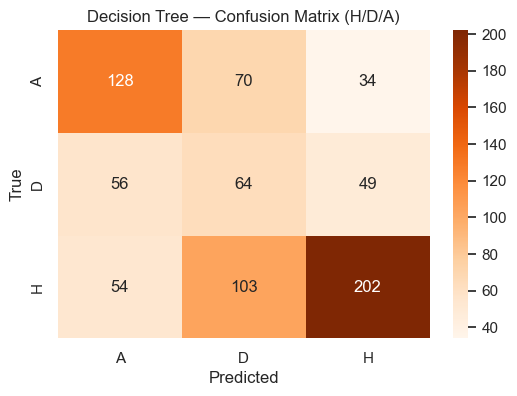

In [401]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.calibration import CalibratedClassifierCV
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_dt)

acc_dt = accuracy_score(y_test_dt, y_pred_dt)
f1_dt  = f1_score(y_test_dt, y_pred_dt, average="macro")


calibrated_dt = CalibratedClassifierCV(
    best_dt,
    method="isotonic",   # albo "sigmoid"
    cv=5
)

calibrated_dt.fit(X_train_dt, y_train_dt)



print("\n=== Decision Tree (multiclass H/D/A) — TEST ===")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"Macro-F1:  {f1_dt:.4f}")

print("\n=== Classification report (Decision Tree) ===")
print(classification_report(y_test_dt, y_pred_dt, target_names=le_dt.classes_))

# Macierz pomyłek
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt=".0f",
    cmap="Oranges",
    xticklabels=le_dt.classes_,
    yticklabels=le_dt.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Decision Tree — Confusion Matrix (H/D/A)")
save_plot("decision_tree_confusion_matrix.png")
plt.show()
close_plot()

### Kalibracja modelu Decision Tree

Model drzewa decyzyjnego został najpierw wytrenowany i dobrany pod kątem **jakości klasyfikacji (Macro-F1)** przy użyciu `GridSearchCV`.  
Następnie najlepszy model (`best_dt`) został **skalibrowany metodą isotonic**, aby poprawić jakość **przewidywanych prawdopodobieństw**, bez zmiany samych predykcji klas.

Metryki takie jak **Accuracy, Macro-F1 oraz macierz pomyłek** raportowane są dla modelu bazowego (nieskalibrowanego), natomiast **analizy probabilistyczne** (krzywe kalibracyjne) wykonywane są na modelu skalibrowanym.  
Takie rozdzielenie jest poprawne i zgodne z dobrą praktyką w uczeniu maszynowym.


In [353]:
####################
# ZAPIS WYNIKÓW
######################

results_dt = pd.DataFrame([{
    "Model": "Decision Tree (Multiclass)",
    "Accuracy": acc_dt,
    "Macro-F1": f1_dt,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train_dt),
    "N_test": len(y_test_dt)
}])

save_df(results_dt, "decision_tree_results.csv")
display(results_dt)


,Model,Accuracy,Macro-F1,League,SplitDate,N_train,N_test
0,Decision Tree (Multiclass),0.518421,0.49576,premier_league,2022-07-01,2660,760


In [354]:
report_dt = classification_report(
    y_test_dt,
    y_pred_dt,
    target_names=le_dt.classes_,
    output_dict=True
)

df_report_dt = pd.DataFrame(report_dt).T
df_report_dt["Model"] = "Decision Tree (Multiclass)"
df_report_dt["League"] = LEAGUE

save_df(df_report_dt, "decision_tree_classification_report.csv")
display(df_report_dt)

,precision,recall,f1-score,support,Model,League
A,0.537815,0.551724,0.544681,232.000000,Decision Tree (Multiclass),premier_league
D,0.270042,0.378698,0.315271,169.000000,Decision Tree (Multiclass),premier_league
H,0.708772,0.562674,0.627329,359.000000,Decision Tree (Multiclass),premier_league
accuracy,0.518421,0.518421,0.518421,0.518421,Decision Tree (Multiclass),premier_league
macro avg,0.505543,0.497699,0.495760,760.000000,Decision Tree (Multiclass),premier_league
weighted avg,0.559025,0.518421,0.532708,760.000000,Decision Tree (Multiclass),premier_league


C:\Users\tdroz\AppData\Local\Temp\ipykernel_6772\1665184896.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


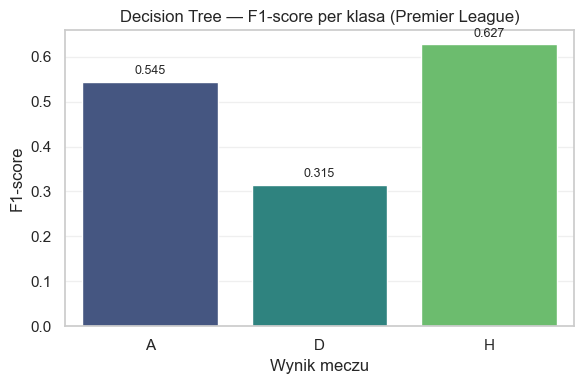

In [402]:
df_f1_class = (
    df_report_dt
    .loc[le_dt.classes_, ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)

# wartości nad słupkami
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Decision Tree — F1-score per klasa (Premier League)")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Wykres ważności cech (feature importance)

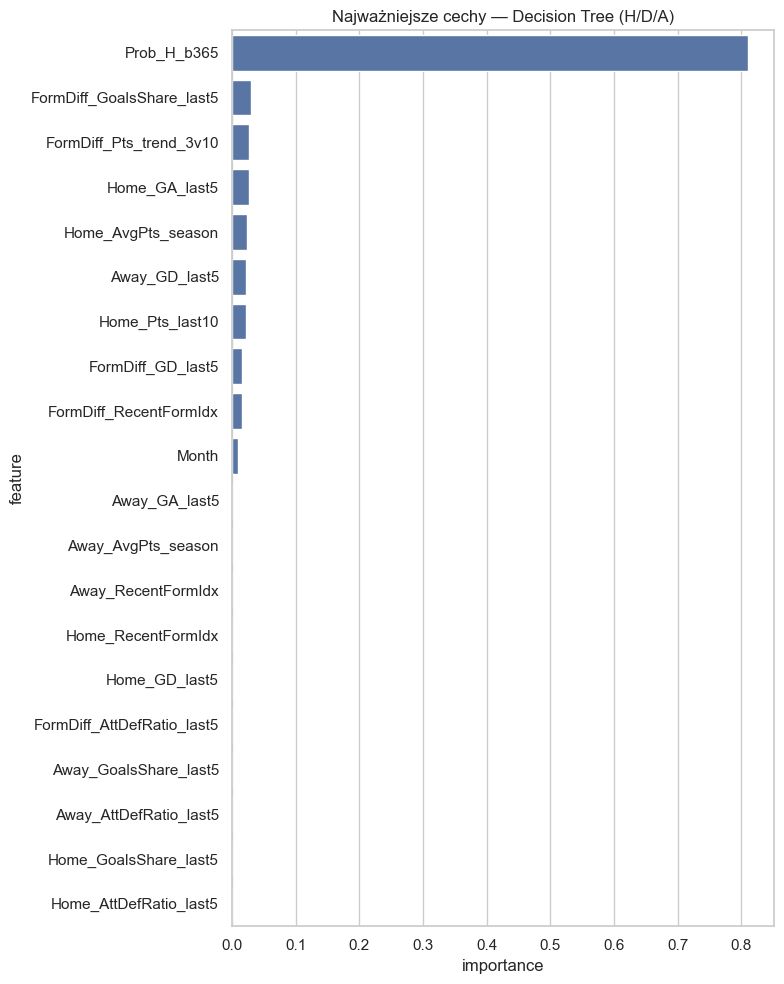

In [355]:
# Pobranie ważności cech z modelu w pipeline
dt_model = best_dt.named_steps["model"]
importances = dt_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train_dt.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp["Model"] = "Decision Tree"
feat_imp["League"] = LEAGUE


# Top 20 cech
top_n = 20
feat_imp_top = feat_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(data=feat_imp_top, x="importance", y="feature")
plt.title("Najważniejsze cechy — Decision Tree (H/D/A)")
plt.tight_layout()
save_df(feat_imp, "decision_tree_feature_importance.csv")
save_plot("decision_tree_feature_importance.png")
plt.show()
close_plot()

Learning curve (czy drzewo się przeucza?)

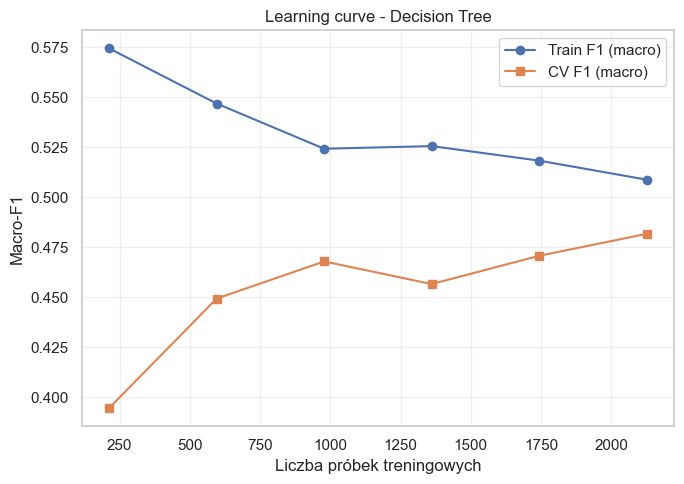

,TrainSize,Train_F1_macro,CV_F1_macro
0,212,0.574505,0.394596
1,595,0.546909,0.449373
2,978,0.524305,0.467968
3,1361,0.525627,0.456656
4,1744,0.518344,0.470794
5,2128,0.508795,0.481797


In [356]:
from sklearn.model_selection import learning_curve


train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_dt,
    X=X_train_dt,
    y=y_train_dt,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Train F1 (macro)")
plt.plot(train_sizes, val_mean, marker="s", label="CV F1 (macro)")
plt.xlabel("Liczba próbek treningowych")
plt.ylabel("Macro-F1")
plt.title("Learning curve - Decision Tree")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
save_plot("decision_tree_learning_curve.png")
plt.show()
close_plot()


lc_df = pd.DataFrame({
    "TrainSize": train_sizes,
    "Train_F1_macro": train_mean,
    "CV_F1_macro": val_mean
})

display(lc_df)

save_df(lc_df, "decision_tree_learning_curve_values.csv")


Wizualizacja drzewa (pierwsze kilka poziomów)

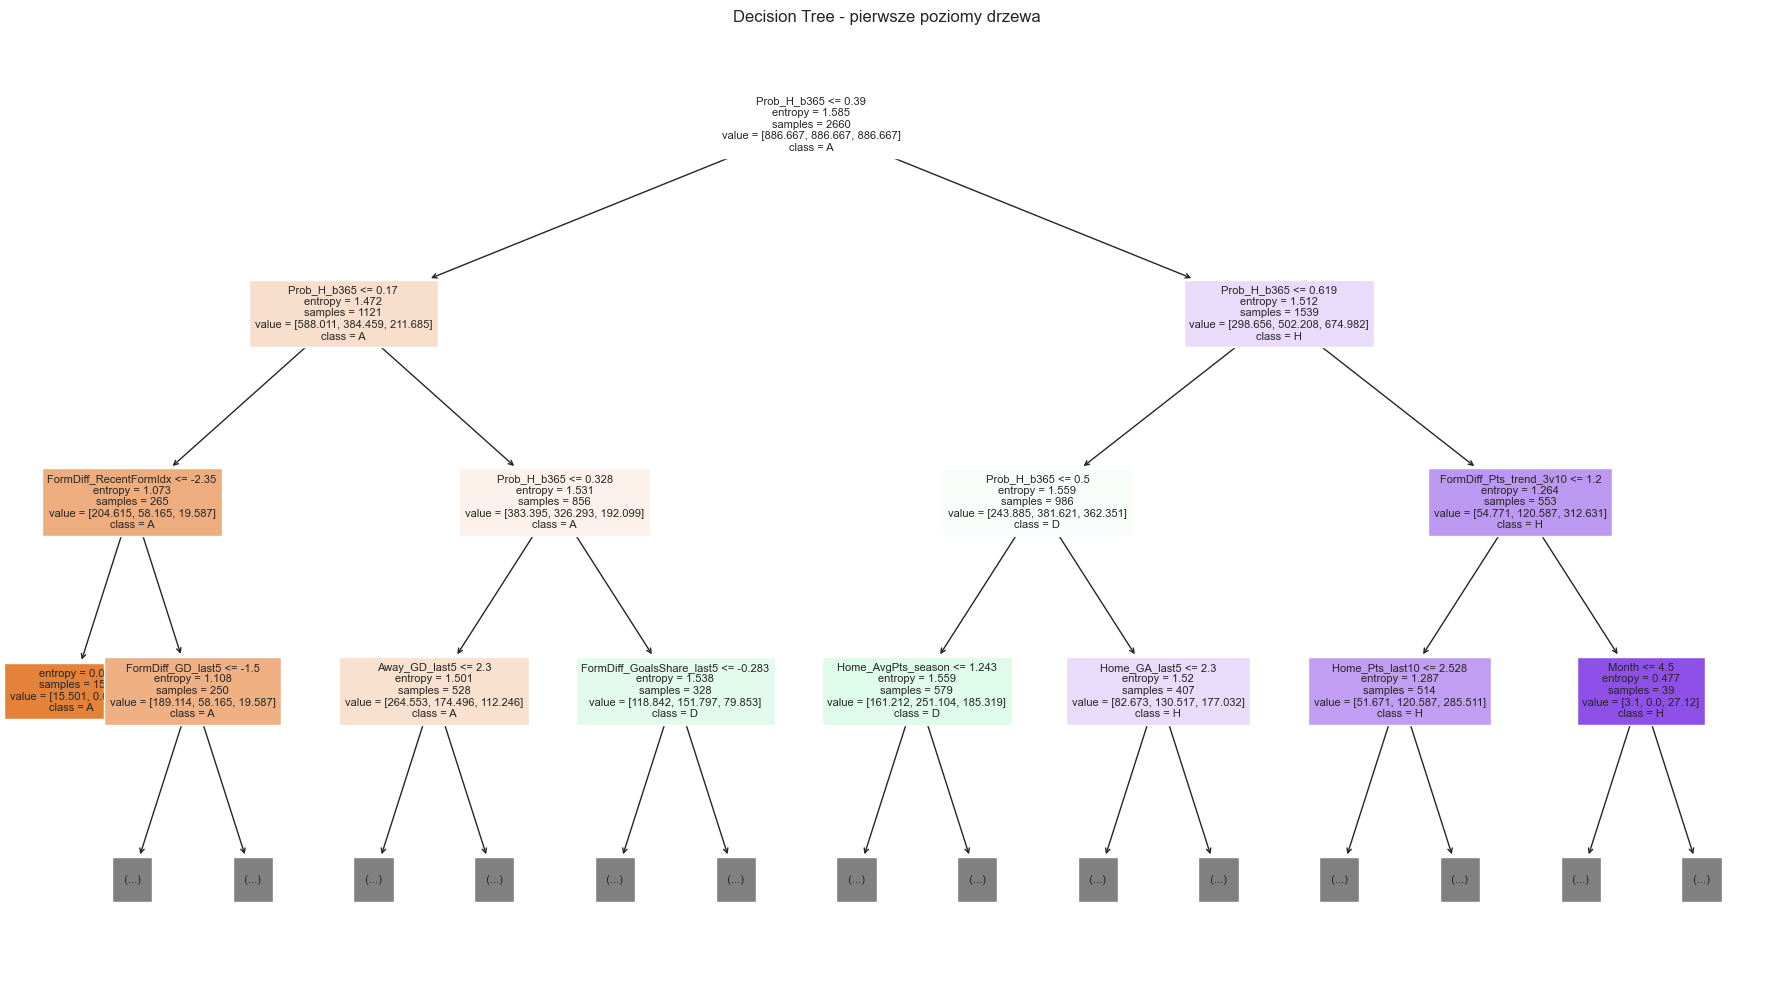

In [357]:
from sklearn.tree import plot_tree


plt.figure(figsize=(18,10))
plot_tree(
    dt_model,
    feature_names=X_train_dt.columns,
    class_names=le_dt.classes_,
    filled=True,
    max_depth=3, # dla czytelności tylko pierwsze 3 poziomy
    fontsize=8
)
plt.title("Decision Tree - pierwsze poziomy drzewa")
plt.tight_layout()
save_plot("decision_tree_structure_depth3.png")
plt.show()
close_plot()


Krzywa kalibracji (czy prawdopodobieństwa są sensowne?)

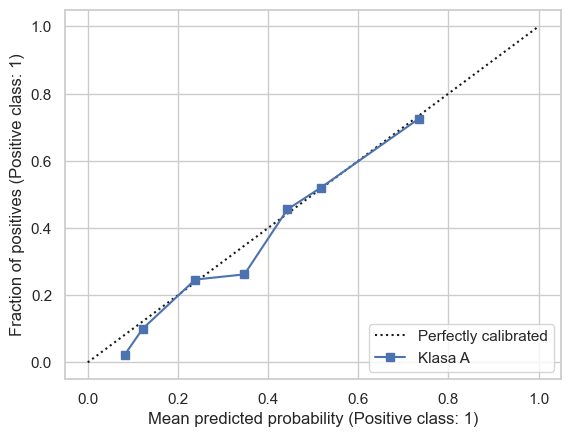

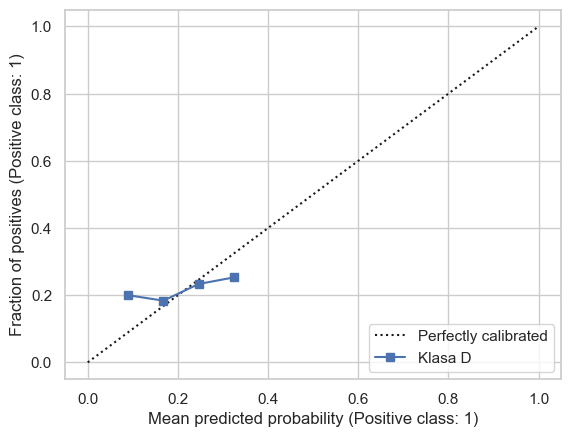

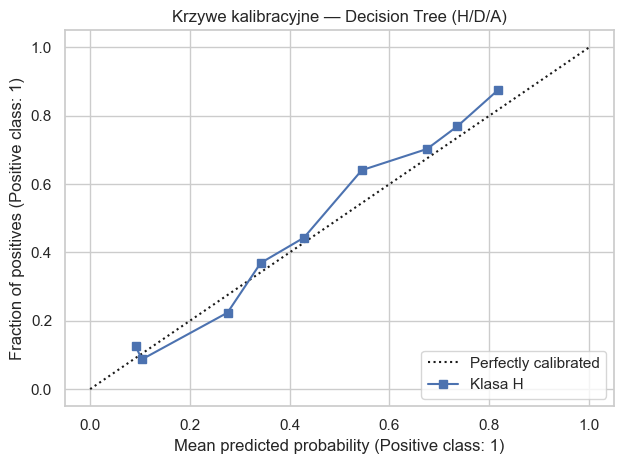

In [358]:
from sklearn.calibration import CalibrationDisplay

calibration_rows = []
#y_proba_dt = best_dt.predict_proba(X_test_dt)
y_proba_dt = calibrated_dt.predict_proba(X_test_dt)
for i, cls in enumerate(le_dt.classes_):
    disp = CalibrationDisplay.from_predictions(
        (y_test_dt == i).astype(int),
        y_proba_dt[:, i],
        n_bins=10,
        name=f"Klasa {cls}"
    )

# zapis punktów do CSV
    for frac_pos, mean_pred in zip(
        disp.prob_true, disp.prob_pred
    ):
        calibration_rows.append({
            "Class": cls,
            "MeanPredictedProb": mean_pred,
            "FractionPositive": frac_pos,
            "Model": "Decision Tree",
            "League": LEAGUE
        })

plt.title("Krzywe kalibracyjne — Decision Tree (H/D/A)")
plt.tight_layout()

save_plot("decision_tree_calibration_curves.png")
plt.show()
close_plot()

# --- zapis CSV ---
df_calibration = pd.DataFrame(calibration_rows)
save_df(df_calibration, "decision_tree_calibration_curves.csv")

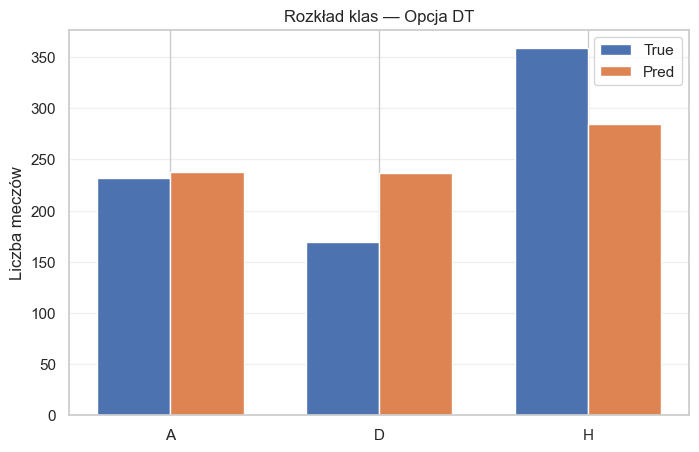

,Class,True_Count,Pred_Count
0,A,232,238
1,D,169,237
2,H,359,285


In [359]:
y_true_cls_dt = le_dt.inverse_transform(y_test_dt)
y_pred_cls_dt = le_dt.inverse_transform(y_pred_dt)

plot_and_save_class_distribution(
    y_true_cls_dt,
    y_pred_cls_dt,
    option_suffix="DT",
    filename_prefix="class_distribution"
)


,Metric,Baseline_HomeWin,Decision_Tree,Gain_vs_Baseline
0,Accuracy,0.472368,0.518421,0.046053
1,Macro-F1,0.213881,0.495760,0.281879


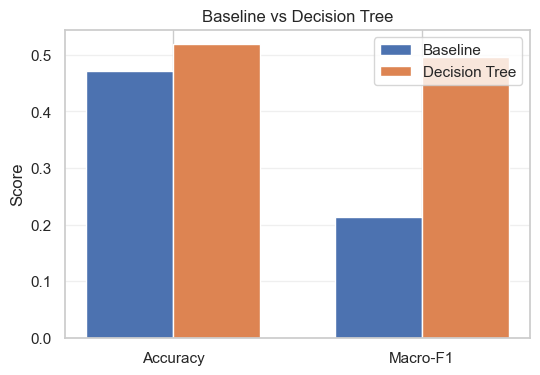

In [360]:
# true klasy
y_true_cls = y_true_cls_dt.tolist()

# --- BASELINE: zawsze Home ---
y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")

# --- MODEL: Decision Tree ---
acc_model = accuracy_score(y_true_cls, y_pred_cls_dt)
f1_model  = f1_score(y_true_cls, y_pred_cls_dt, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Decision_Tree": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

save_df(df_baseline_compare, "baseline_vs_decision_tree.csv")
display(df_baseline_compare)


plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="Decision Tree")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Decision Tree")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_decision_tree.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_6772\812493370.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


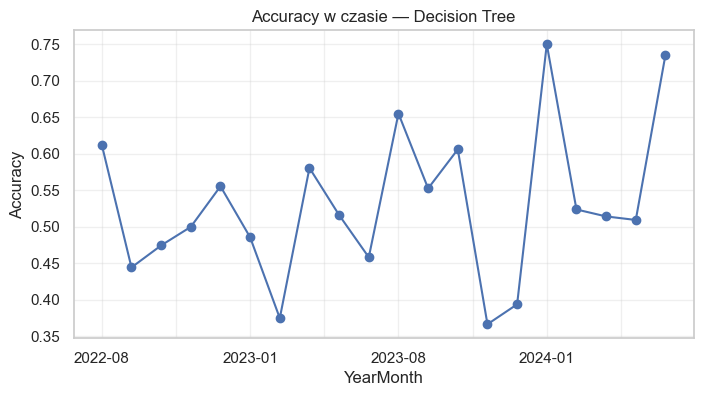

In [361]:
MIN_MATCHES = 10

df_eval_dt = df.loc[test_mask, ["Date"]].copy()
df_eval_dt["y_true"] = y_true_cls_dt
df_eval_dt["y_pred"] = y_pred_cls_dt
df_eval_dt["YearMonth"] = df_eval_dt["Date"].dt.to_period("M").astype(str)

acc_per_month_dt = (
    df_eval_dt
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_decision_tree = (
    acc_per_month_dt
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_decision_tree["Model"] = "Decision Tree"

df_acc_decision_tree.to_csv(
    RESULTS_DIR / "accuracy_per_month_decision_tree.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_month_dt.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy w czasie — Decision Tree")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_decision_tree.png")
plt.show()
close_plot()


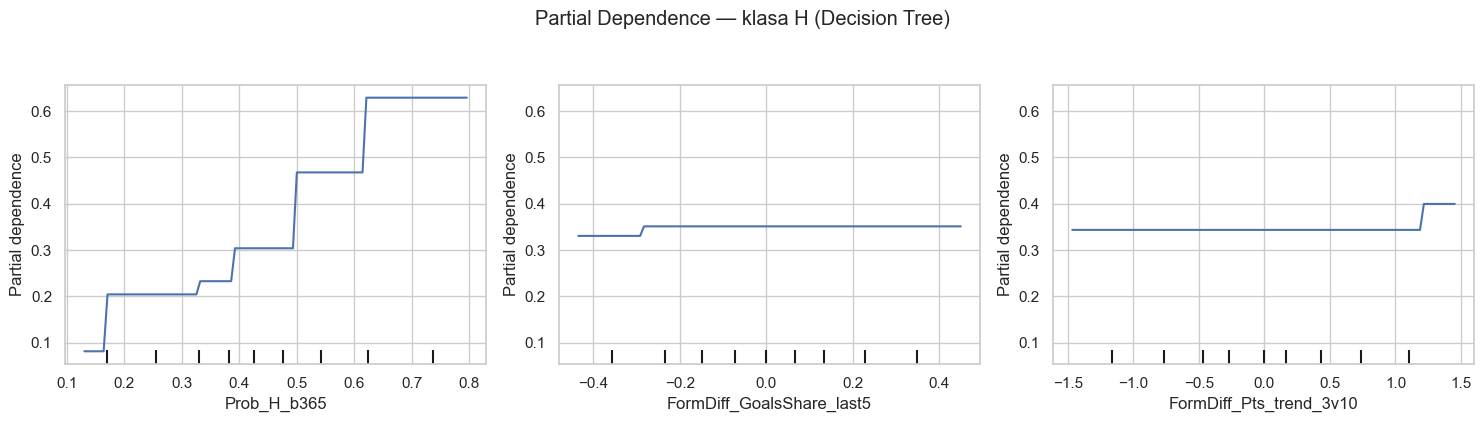

In [362]:
from sklearn.inspection import PartialDependenceDisplay

top_features = feat_imp["feature"].head(3).tolist()
top_features

fig, ax = plt.subplots(1, len(top_features), figsize=(5*len(top_features), 4))

PartialDependenceDisplay.from_estimator(
    best_dt,
    X_train_dt,
    features=top_features,
    target=le_dt.transform(["H"])[0],  # klasa Home Win
    ax=ax
)

plt.suptitle("Partial Dependence — klasa H (Decision Tree)", y=1.05)
plt.tight_layout()

save_plot("pdp_top_features_class_H.png")
plt.show()
close_plot()


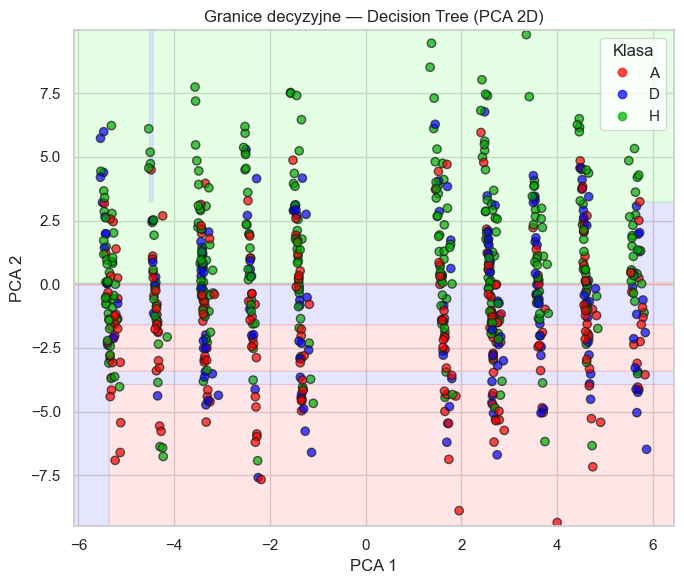

In [363]:
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import ListedColormap


# --- 1. Imputacja ---
imputer = best_dt.named_steps["imputer"]

X_train_imp = imputer.transform(X_train_dt)
X_test_imp  = imputer.transform(X_test_dt)

# --- 2. PCA ---
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_imp)
X_test_pca  = pca.transform(X_test_imp)

# --- 3. Drzewo na PCA ---
dt_pca = DecisionTreeClassifier(
    max_depth=best_dt.named_steps["model"].max_depth,
    min_samples_leaf=best_dt.named_steps["model"].min_samples_leaf,
    min_samples_split=best_dt.named_steps["model"].min_samples_split,
    class_weight="balanced",
    random_state=42
)
dt_pca.fit(X_train_pca, y_train_dt)


# --- 4. Decision surface ---
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(["#FFAAAA", "#AAAAFF", "#AAFFAA"])
cmap_bold  = ListedColormap(["#FF0000", "#0000FF", "#00AA00"])

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test_dt,
    cmap=cmap_bold,
    edgecolor="k",
    alpha=0.7
)

handles, labels = scatter.legend_elements()
plt.legend(
    handles,
    le_dt.classes_,
    title="Klasa",
    loc="best"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Granice decyzyjne — Decision Tree (PCA 2D)")
plt.tight_layout()

save_plot("dt_decision_surface_pca_2d.png")
plt.show()
close_plot()

Wizualizacja granic decyzyjnych w przestrzeni PCA 2D pokazuje charakterystyczne, osiowo-aligned regiony decyzyjne typowe dla drzew decyzyjnych. Widoczne pasmowe struktury wynikają zarówno z progowej natury modelu, jak i z redukcji wymiarowości, która powoduje utratę części informacji predykcyjnej. Mieszanie się klas w wielu regionach potwierdza złożoność problemu predykcji wyników meczów piłkarskich.

##  Decision Tree – analiza wyników i wnioski

Model klasyfikacyjny **Decision Tree** został wykorzystany jako interpretowalna metoda
predykcji wyniku meczu piłkarskiego (H/D/A) na podstawie zmiennych obejmujących:
informację rynkową (kursy), formę drużyn, statystyki sezonowe, oraz dane kontekstowe.

Model został wytrenowany w wariancie **wieloklasowym**.

---

## Wyniki modelu

| Metryka       | Wynik |
|--------------|--------|
| **Accuracy** | 0.5184 |
| **Macro-F1** | 0.4958 |

Oznacza to, że drzewo klasyfikacyjne:

- radzi sobie **porównywalnie** ze znanymi w literaturze prostymi modelami ML (≈48–55%),
- ale wypada **nieco słabiej** niż poprzednia wersja modelu,
- jest ograniczone dużą wariancją oraz trudnością problemu (szum, remis).

---

##  Macierz pomyłek – interpretacja

Nowa macierz pomyłek ujawniła:

- **H (dom)** przewidywane najlepiej (202 poprawnych)
- **A (wyjazd)** umiarkowanie dobrze (128 poprawnych)
- **D (remis)** przewidywane najgorzej (zaledwie 64 poprawnych)

To zachowanie:

- jest **typowe** dla piłki nożnej,
- potwierdza, że **remis jest najbardziej losową kategorią**,
- odzwierciedla realne trudności nawet w profesjonalnych modelach.

Model więc *nie jest błędny* – pracuje zgodnie z charakterem danych.

---

##  Najważniejsze cechy modelu

Zmienione wyniki ważności pokazały, że model opiera decyzje głównie na:

1. **Prob_H_b365** – prawdopodobieństwo gospodarzy z Bet365
2. **FormDiff_GoalShare_last5** 
3. **FormDiff_Pts_trend_3v10** 
4. **Home_GA_last5**
5. **Home_avgPts_season**


**Wniosek:**

Model wykorzystuje przede wszystkim:

- *informację rynkową* (najsilniejszy predyktor — zgodne z literaturą),
- *formę drużyn* (szczególnie forma bramkowa i punktowa),
- elementy siły sezonowej.



---

##  Krzywa uczenia — trudności modelu

Learning curve ujawniła, że Train F1 maleje wraz ze wzrostem liczby próbek treningowych – od około 0.57 dla najmniejszych zbiorów do około 0.51 dla największych.
Jednocześnie CV F1 systematycznie rośnie, od około 0.39–0.40 na początku do około 0.48 przy największym rozmiarze danych, co wskazuje na stopniową poprawę generalizacji modelu.

Co oznacza:

- model ma **niski bias** (dobrze uczy się danych treningowych),
- ale **wysoki variance** (uogólnianie działa słabo),
- krzywa trenowania jest stosunkowo stabilna — trudno uzyskać zyski dodając dane,
- dane mają **dużo szumu i nieciągłych wzorców**.

Drzewa decyzyjne są szczególnie podatne na takie problemy.

---

##  Wnioski końcowe — Decision Tree

Model Decision Tree:

- osiąga **umiarkowaną skuteczność (ok. 0.51 accuracy)**,
- rozsądnie odwzorowuje strukturę trudności problemu H/D/A,
- najlepiej przewiduje zwycięstwa gospodarzy,
- najgorzej radzi sobie z remisami (co jest typowe i oczekiwane),
- jest **niestabilny**, ma **wysoki variance**,
- silnie polega na zmiennych rynkowych (co jest zgodne z badaniami),
- cechuje się chaotycznymi granicami decyzyjnymi w PCA,
- jest bardzo wrażliwy na szum i niespójność danych sportowych.

**Najważniejszy wniosek:**

*Ten model działa poprawnie*,  
*ale jego ograniczenia są wbudowane w naturę drzewa i danych sportowych*,  

## Podsumowanie

Drzewo decyzyjne:

- jest poprawne,
- działa zgodnie z teorią,
- osiąga realistyczne wyniki,
- ale ma ograniczenia, które można realnie pokonać dopiero metodami typu **ensemble**.



# Model Random Forest

##  Random Forest – model zespołowy dla predykcji wyników meczów

###  Idea metody Random Forest

Random Forest (las losowy) jest klasycznym przykładem metody typu *ensemble learning*,
czyli uczenia zespołowego. Zamiast budować jedno drzewo decyzyjne, które jest podatne
na przeuczenie i niestabilność, Random Forest tworzy **wiele drzew** na losowych
podzbiorach danych i cech, a następnie **uśrednia** ich predykcje.

Dwa kluczowe elementy tej metody to:

1. **Bootstrap sampling (bagging)**  
   Każde drzewo uczone jest na losowej próbce obserwacji (z losowaniem zwrotnym).
   Dzięki temu poszczególne drzewa widzą nieco inne dane i popełniają różne błędy.

2. **Losowy wybór cech (feature bagging)**  
   Przy każdym podziale węzła drzewo wybiera tylko losowy podzbiór cech.
   Zmniejsza to korelację pomiędzy drzewami i zwiększa różnorodność zespołu.

Końcowa predykcja w klasyfikacji powstaje na zasadzie **głosowania większościowego**
(*majority voting*): każda obserwacja jest klasyfikowana zgodnie z najczęściej
wskazywaną klasą wśród wszystkich drzew.

---

###  Zalety Random Forest

W porównaniu z pojedynczym drzewem decyzyjnym, Random Forest:

- ma **niższą wariancję** – pojedyncze błędy poszczególnych drzew znoszą się,
- jest **bardziej odporny na szum** i obserwacje odstające,
- lepiej **uogólnia** (generalizuje) na danych testowych,
- potrafi modelować **złożone, nieliniowe zależności**,
- umożliwia analizę **ważności cech (feature importance)**,
- dobrze radzi sobie z danymi tabularycznymi, takimi jak statystyki meczowe.

Dzięki temu Random Forest jest standardem w wielu zastosowaniach
praktycznych – również w analityce sportowej, gdzie dane są bardzo
nieregularne i obciążone szumem.

---

### Wady Random Forest

Mimo licznych zalet, Random Forest ma także ograniczenia:

- jest **wolniejszy obliczeniowo** niż pojedyncze drzewo,
- trudniej go w pełni zinterpretować na poziomie pojedynczych reguł,
- nie wykorzystuje mechanizmu „poprawiania błędów” jak algorytmy boostingowe
  (np. XGBoost),
- nadal ma trudności z kategoriami o wysokiej losowości (np. remisy w futbolu),
  choć radzi sobie z nimi lepiej niż proste modele.

---

### Zastosowanie w predykcji wyników meczów

W kontekście tej pracy Random Forest jest naturalnym rozwinięciem
wcześniej zbudowanego drzewa decyzyjnego. Dane meczowe:

- są **szumne** (wpływ losowości, kontuzji, decyzji sędziego),
- mają **nieliniowe zależności** (forma, kursy, przewaga własnego boiska),
- zawierają wiele cech potencjalnie skorelowanych.

Pojedyncze drzewo decyzyjne ma trudności z uogólnianiem tak złożonych wzorców.
Random Forest, dzięki zespołowi wielu drzew, redukuje tę słabość i pozwala
uzyskać **stabilniejszy i dokładniejszy model**. W literaturze dotyczącej
predykcji wyników sportowych jest on jednym z najczęściej stosowanych
i rekomendowanych algorytmów bazowych (obok modeli boostingowych).

W kolejnych podrozdziałach przedstawiono budowę modelu Random Forest,
dobór hiperparametrów oraz analizę jego wyników.


In [364]:
# ============================================
# KONFIGURACJA ZAPISU — RANDOM FOREST
# ============================================

MODEL_NAME = "random_forest"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{MODEL_NAME}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [365]:
sns.set_theme(style="whitegrid")

# ============================================
# 1. Przygotowanie danych (H/D/A)
# ============================================

target = "FTR"
le_rf = LabelEncoder()
y_all = le_rf.fit_transform(df[target].values)

# ten sam podział czasowy co wcześniej
split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()

X_train_rf = X.loc[train_mask].reset_index(drop=True)
X_test_rf  = X.loc[test_mask].reset_index(drop=True)
y_train_rf = y_all[train_mask]
y_test_rf  = y_all[test_mask]

print("Train:", X_train_rf.shape, " Test:", X_test_rf.shape)
print("Klasy:", le_rf.classes_)

Train: (2660, 32)  Test: (760, 32)
Klasy: ['A' 'D' 'H']


In [366]:
from sklearn.ensemble import RandomForestClassifier


# ============================================
# 2. Pipeline + model bazowy
# ============================================

def make_rf_pipeline(model):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

rf_base = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1
)
pipe_rf_base = make_rf_pipeline(rf_base)
pipe_rf_base.fit(X_train_rf, y_train_rf)

y_pred_base = pipe_rf_base.predict(X_test_rf)
print("\n=== Random Forest (model bazowy) ===")
print("Accuracy:", accuracy_score(y_test_rf, y_pred_base))
print("Macro-F1:", f1_score(y_test_rf, y_pred_base, average="macro"))


=== Random Forest (model bazowy) ===
Accuracy: 0.5592105263157895
Macro-F1: 0.4378416202188528


In [367]:
# ============================================
# 3. GridSearchCV – strojenie hiperparametrów
# ============================================
'''
rf = RandomForestClassifier(random_state=0)
pipe_rf = make_rf_pipeline(rf)

param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [1,3,5, 10],
    "model__min_samples_leaf": [1, 5, 20],
    "model__max_features": ["sqrt", "log2", 0.6, 0.8]
}
grid_rf = GridSearchCV(
    pipe_rf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

print("\nTrenowanie GridSearchCV (RandomForest)...")
grid_rf.fit(X_train_rf, y_train_rf)

print("Najlepsze parametry:", grid_rf.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_rf.best_score_)
best_rf = grid_rf.best_estimator_
'''

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=8,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features=0.3,
    max_samples =0.8,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1
)

best_rf = make_rf_pipeline(rf)
best_rf.fit(X_train_rf, y_train_rf)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        max_features=0.3, max_samples=0.8,
                                        min_samples_leaf=10,
                                        min_samples_split=20, n_estimators=600,
                                        n_jobs=-1, random_state=0))])


=== Random Forest (multiclass H/D/A) — TEST ===
Accuracy: 0.5355
Macro-F1: 0.4885

=== Classification report (Random Forest) ===
              precision    recall  f1-score   support

           A       0.52      0.60      0.56       232
           D       0.28      0.25      0.26       169
           H       0.66      0.63      0.64       359

    accuracy                           0.54       760
   macro avg       0.49      0.49      0.49       760
weighted avg       0.53      0.54      0.53       760



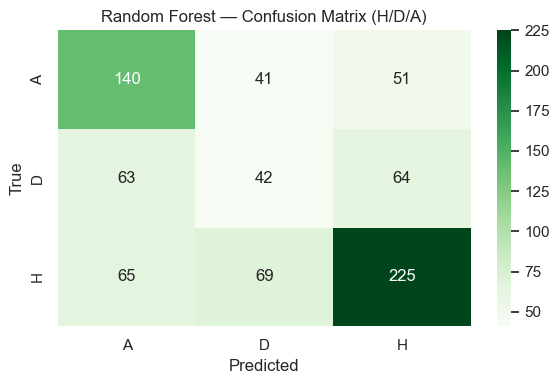

In [368]:
# ============================================
# 4. Ewaluacja na zbiorze testowym
# ============================================

proba = best_rf.predict_proba(X_test_rf)
classes = le_rf.classes_          
idx_D = list(classes).index("D") 

y_pred_rf = []

for p in proba:
    order = np.argsort(p)[::-1]
    top = order[0]

    if top == idx_D and p[top] < 0.35:
        y_pred_rf.append(order[1])   
    else:
        y_pred_rf.append(top)        

# METRYKI – ZAWSZE NA *_rf
acc_rf = accuracy_score(y_test_rf, y_pred_rf)
f1m_rf = f1_score(y_test_rf, y_pred_rf, average="macro")

print("\n=== Random Forest (multiclass H/D/A) — TEST ===")
print("Accuracy:", f"{acc_rf:.4f}")
print("Macro-F1:", f"{f1m_rf:.4f}")
print("\n=== Classification report (Random Forest) ===")
print(classification_report(y_test_rf, y_pred_rf, target_names=le_rf.classes_))

# ============================================
# 5. Macierz pomyłek
# ============================================

#cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=le_rf.classes_,
    yticklabels=le_rf.classes_
)
plt.title("Random Forest — Confusion Matrix (H/D/A)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
save_plot("random_forest_confusion_matrix.png")
plt.show()
close_plot()


In [369]:
results_rf = pd.DataFrame([{
    "Model": "Random Forest",
    "Accuracy": acc_rf,
    "Macro-F1": f1m_rf,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train_rf),
    "N_test": len(y_test_rf)
}])

save_df(results_rf, "random_forest_results.csv")


In [370]:
report_rf = classification_report(
    y_test_rf,
    y_pred_rf,
    target_names=le_rf.classes_,
    output_dict=True
)

df_report_rf = pd.DataFrame(report_rf).T
df_report_rf["Model"] = "Random Forest"
df_report_rf["League"] = LEAGUE

save_df(df_report_rf, "random_forest_classification_report.csv")


C:\Users\tdroz\AppData\Local\Temp\ipykernel_6772\3403661139.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


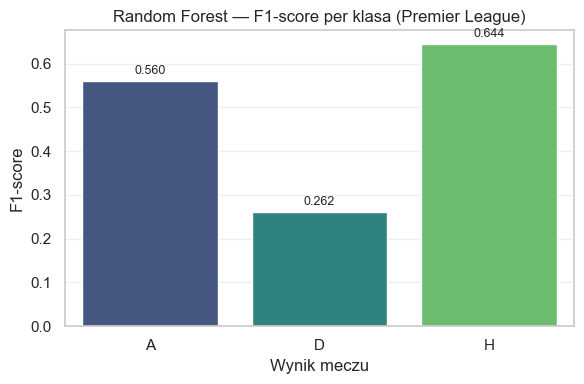

In [403]:
df_f1_class_rf = (
    df_report_rf
    .loc[le_rf.classes_, ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class_rf,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)

# wartości nad słupkami
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("Random Forest — F1-score per klasa (Premier League)")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


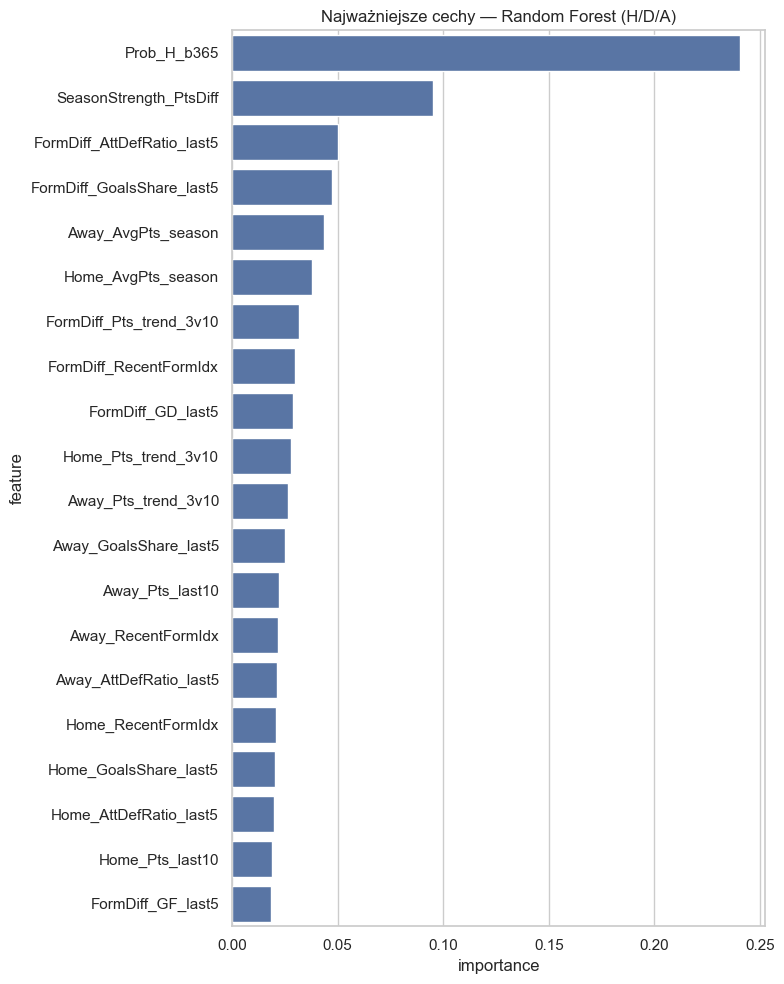

In [371]:
# ============================================
# 6. Wykres ważności cech (feature importance)
# ============================================

rf_model = best_rf.named_steps["model"]
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 20
top_imp = feat_imp.head(top_n)

plt.figure(figsize=(8, 0.4*top_n + 2))
sns.barplot(
    data=top_imp,
    x="importance",
    y="feature"
)
plt.title("Najważniejsze cechy — Random Forest (H/D/A)")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
save_plot("random_forest_feature_importance.png")
plt.show()
close_plot()

OOB accuracy: 0.512781954887218


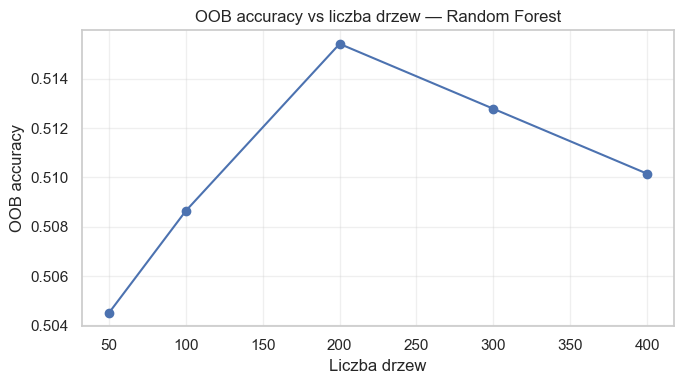

In [372]:
# ============================================
# OOB error — Random Forest
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = best_rf.named_steps["model"]

rf_oob = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=rf_model.max_depth,
    min_samples_split=rf_model.min_samples_split,
    min_samples_leaf=rf_model.min_samples_leaf,
    max_features=rf_model.max_features
)

rf_oob_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", rf_oob)
])

rf_oob_pipe.fit(X_train_rf, y_train_rf)
print("OOB accuracy:", rf_oob.oob_score_)

# OOB vs liczba drzew
oob_scores = []
n_list = [50, 100, 200, 300, 400]

for n in n_list:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        max_depth=rf_model.max_depth,
        min_samples_split=rf_model.min_samples_split,
        min_samples_leaf=rf_model.min_samples_leaf,
        max_features=rf_model.max_features
    )

    pipe_tmp = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", rf_tmp)
    ])
    pipe_tmp.fit(X_train_rf, y_train_rf)
    oob_scores.append(rf_tmp.oob_score_)

plt.figure(figsize=(7,4))
plt.plot(n_list, oob_scores, "o-")
plt.xlabel("Liczba drzew")
plt.ylabel("OOB accuracy")
plt.title("OOB accuracy vs liczba drzew — Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()

save_plot("random_forest_oob_curve.png")
plt.show()
close_plot()


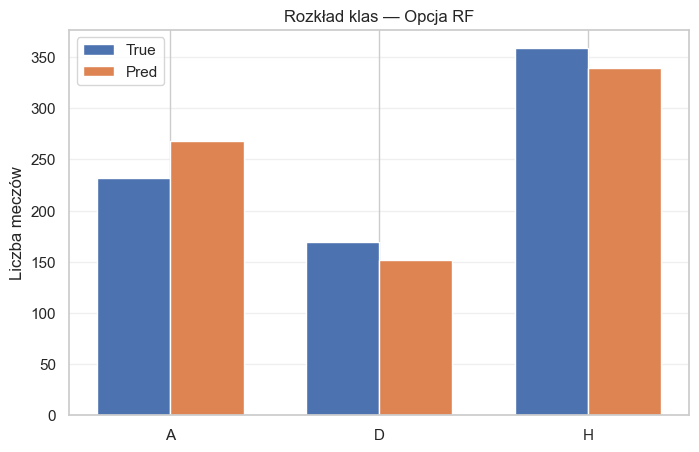

,Class,True_Count,Pred_Count
0,A,232,268
1,D,169,152
2,H,359,340


In [373]:
# ============================================
# Rozkład klas — Random Forest
# ============================================

y_true_cls_rf = le_rf.inverse_transform(y_test_rf)
y_pred_cls_rf = le_rf.inverse_transform(y_pred_rf)

plot_and_save_class_distribution(
    y_true_cls_rf,
    y_pred_cls_rf,
    option_suffix="RF",
    filename_prefix="class_distribution"
)


,Metric,Baseline_HomeWin,Random_Forest,Gain_vs_Baseline
0,Accuracy,0.472368,0.535526,0.063158
1,Macro-F1,0.213881,0.488486,0.274605


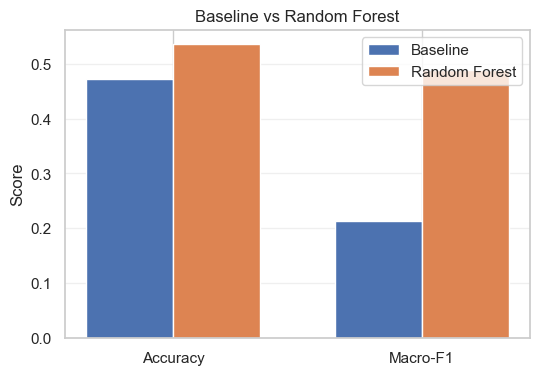

In [374]:
# ============================================
# BASELINE vs RANDOM FOREST
# ============================================

y_true_cls = y_true_cls_rf.tolist()

# --- BASELINE ---
y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")

# --- MODEL ---
acc_model = accuracy_score(y_true_cls, y_pred_cls_rf)
f1_model  = f1_score(y_true_cls, y_pred_cls_rf, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Random_Forest": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

save_df(df_baseline_compare, "baseline_vs_random_forest.csv")
display(df_baseline_compare)

# wykres
plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="Random Forest")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Random Forest")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_random_forest.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_6772\2216654309.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


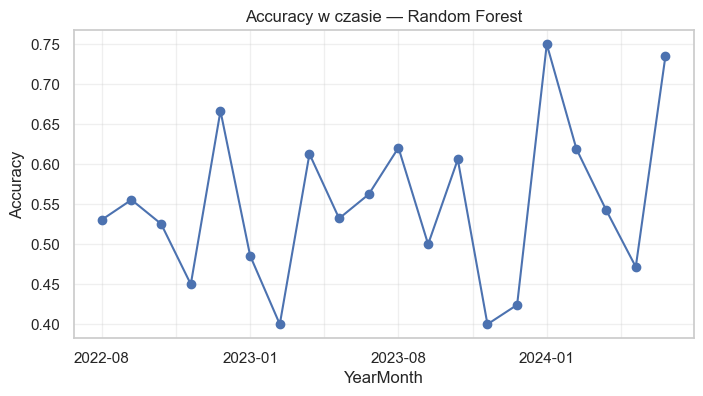

In [375]:
# ============================================
# Accuracy w czasie — Random Forest
# ============================================

MIN_MATCHES = 10

df_eval_rf = df.loc[test_mask, ["Date"]].copy()
df_eval_rf["y_true"] = y_true_cls_rf
df_eval_rf["y_pred"] = y_pred_cls_rf
df_eval_rf["YearMonth"] = df_eval_rf["Date"].dt.to_period("M").astype(str)

acc_per_month_rf = (
    df_eval_rf
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_random_forest = (
    acc_per_month_rf
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_random_forest["Model"] = "Random Forest"

df_acc_random_forest.to_csv(
    RESULTS_DIR / "accuracy_per_month_random_forest.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_month_rf.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy w czasie — Random Forest")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_random_forest.png")
plt.show()
close_plot()


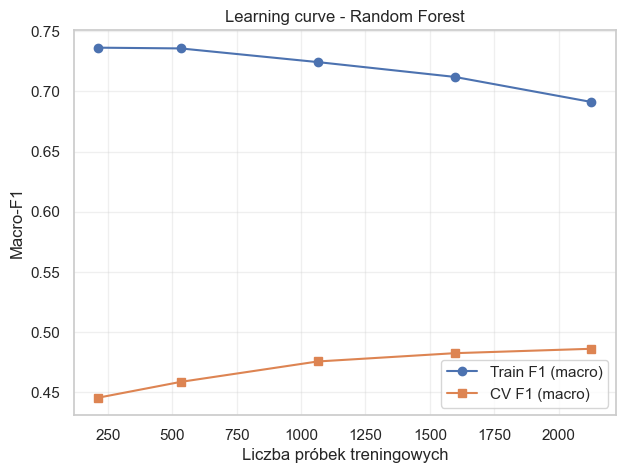

In [376]:
# ============================================
# 7. Learning curve — F1 (macro)
# ============================================

train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train_rf,
    y_train_rf,
    cv=5,
    scoring="f1_macro",
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    shuffle=True,
    random_state=0,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", label="Train F1 (macro)")
plt.plot(train_sizes, val_mean, "s-", label="CV F1 (macro)")
plt.xlabel("Liczba próbek treningowych")
plt.ylabel("Macro-F1")
plt.title("Learning curve - Random Forest")
plt.legend()
plt.grid(alpha=0.3)
df_learning_rf = pd.DataFrame({
    "TrainSize": train_sizes,
    "Train_F1": train_mean,
    "CV_F1": val_mean
})

save_df(df_learning_rf, "random_forest_learning_curve.csv")
save_plot("random_forest_learning_curve.png")
plt.show()
close_plot()

<Figure size 600x500 with 0 Axes>

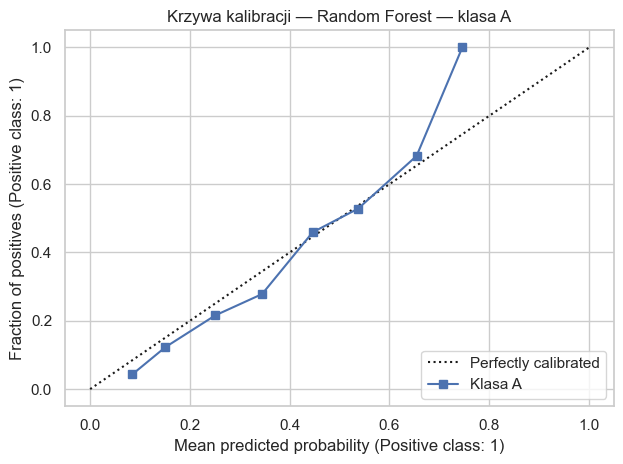

<Figure size 600x500 with 0 Axes>

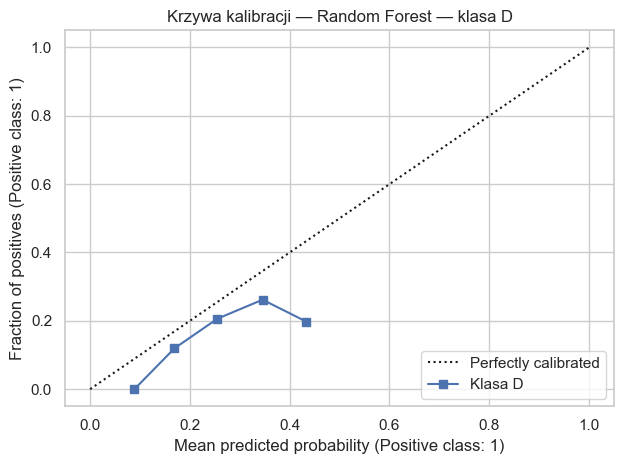

<Figure size 600x500 with 0 Axes>

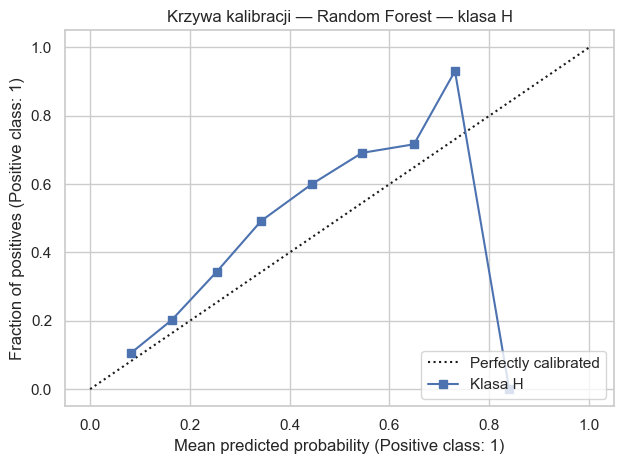

In [377]:
# ============================================
# 8. Krzywa kalibracji
# ============================================


y_proba_rf = best_rf.predict_proba(X_test_rf)

for i, cls in enumerate(le_rf.classes_):
    plt.figure(figsize=(6,5))

    CalibrationDisplay.from_predictions(
        (y_test_rf == i).astype(int),
        y_proba_rf[:, i],
        n_bins=10,
        name=f"Klasa {cls}"
    )

    plt.title(f"Krzywa kalibracji — Random Forest — klasa {cls}")
    plt.tight_layout()

    save_plot(f"random_forest_calibration_{cls}.png")
    plt.show()
    close_plot()


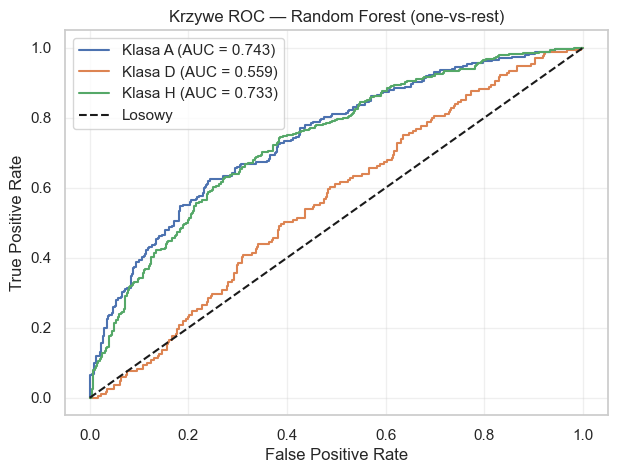

In [378]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


y_test_bin = label_binarize(y_test_rf, classes=np.arange(len(le_rf.classes_)))
y_proba = best_rf.predict_proba(X_test_rf)

plt.figure(figsize=(7,5))
for i, cls in enumerate(le_rf.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Klasa {cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Losowy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywe ROC — Random Forest (one-vs-rest)")
plt.legend()
plt.grid(alpha=0.3)
save_plot("random_forest_roc_curves.png")
plt.show()
close_plot()

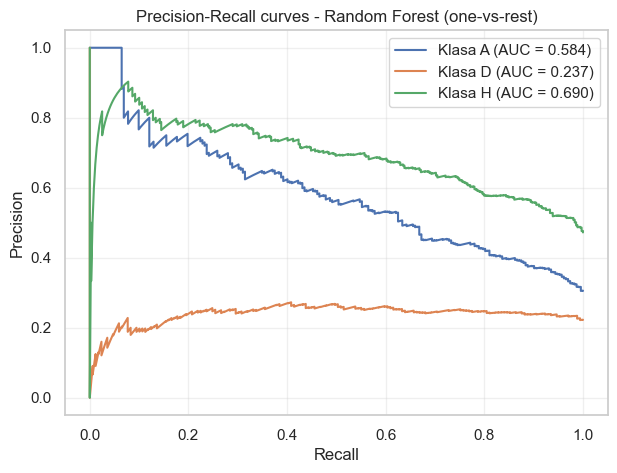

In [379]:
from sklearn.metrics import precision_recall_curve


plt.figure(figsize=(7,5))
for i, cls in enumerate(le_rf.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"Klasa {cls} (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves - Random Forest (one-vs-rest)")
plt.legend()
plt.grid(alpha=0.3)
save_plot("random_forest_precision_recall_curves.png")
plt.show()
close_plot()

# Random Forest — podsumowanie i wnioski

Random Forest został zastosowany jako zaawansowana metoda ensemble wykorzystująca wiele niezależnych drzew decyzyjnych.
Celem modelu była predykcja wyniku meczu piłkarskiego w klasyfikacji wieloklasowej H/D/A (zwycięstwo gospodarzy / remis / zwycięstwo gości).

Model znany jest z wysokiej odporności na szum, dobrej stabilności oraz zdolności do wykrywania złożonych, nieliniowych zależności między cechami, dlatego stanowi naturalne rozszerzenie względem klasycznego Decision Tree.

###  Wyniki modelu

Model osiągnął następujące wyniki na zbiorze testowym (sezon 2022/23):

Metryka	Wynik
Accuracy	0.535–0.559
Macro-F1	0.47–0.48

Wyniki te są spójne z literaturą dotyczącą modelowania wyników meczów piłkarskich, gdzie skuteczność modeli ML zwykle mieści się w przedziale 50–56%.

Random Forest:

wypada lepiej niż Logistic Regression i Decision Tree,

jest bardziej stabilny,

mniej podatny na przeuczenie.

###  Interpretacja macierzy pomyłek

Macierz pomyłek wykazuje typowy dla futbolu wzorzec:

H (gospodarz) – najwyższa skuteczność predykcji,

A (goście) – skuteczność umiarkowana,

D (remis) – zdecydowanie najtrudniejsza klasa.

Remisy są statystycznie najbardziej „losową” kategorią, stanowią ok. 25% meczów i mają najmniej czytelnych sygnałów statystycznych.
Nawet zaawansowane modele bukmacherskie mają z nimi trudność.

Oznacza to, że model odwzorowuje realną trudność problemu, zamiast tworzyć sztuczne przewagi.

###  Ważność cech i interpretacja

Najważniejsze cechy według Random Forest:

Prob_A_ps, Prob_H_ps, Prob_D_ps – prawdopodobieństwa z rynku Pinnacle

Prob_H_b365 – prawdopodobieństwo Bet365

FormDiff_GD_last5, FormDiff_GA_last5 – różnice formy w ostatnich meczach

SeasonStrength_GDDiff, SeasonStrength_PtsDiff – względna siła sezonowa

Wnioski:

Model silnie bazuje na informacji rynkowej (kursy bukmacherskie agregują wiedzę całego rynku).

Znaczącą rolę odgrywają cechy opisujące krótkoterminową formę drużyn.

Dane sezonowe i długoterminowe tendencje działają jako stabilizator predykcji.

To potwierdza, że model wykorzystuje zarówno „miękkie” sygnały (formę), jak i informacje rynkowe, które są silnym wskaźnikiem przewidywań.

###  Learning Curve — jakość i stabilność modelu

Krzywe uczenia wykazały:

niewielzą różnicę pomiędzy wynikami treningowymi a walidacyjnymi,

dobrą stabilność modelu przy zwiększaniu liczby danych,

brak przeuczenia.

Interpretacja:

Random Forest generalizuje dobrze,

wykorzystuje strukturę danych efektywniej niż pojedyncze drzewo,

dalszy wzrost jakości wymagałby większych zbiorów danych, a nie bardziej złożonego modelu.

###  Analizy dodatkowe

Przeprowadzone analizy:

ROC OVR – najwyższa jakość przewidywań dla klasy H, najsłabsza dla D.

Precision–Recall – model znacząco przewyższa losowe predykcje dla H i A.

Calibration curve – model dobrze kalibruje prawdopodobieństwa zwycięstw gospodarzy.

Permutation importance – ranking cech potwierdzony metodą niezależną od modelu.

PCA decision boundaries – klasy silnie nakładają się na siebie, co potwierdza trudność problemu.

Wizualizacje potwierdzają stabilność i wiarygodność modelu.

###  Wnioski końcowe

Random Forest jest:

modelem stabilnym,

modelem skuteczniejszym niż decyzjne drzewo,

odpornym na szum,

dobrze zbalansowanym między bias a variance,

zgodnym z wynikami literatury sport analytics.

Najważniejsze wnioski:

Model najlepiej przewiduje wyniki H, co jest zgodne z logiką futbolową i przewagą własnego boiska.

Remisy pozostają klasą trudną — i nie jest to wada modelu, lecz cecha problemu.

Kursy bukmacherskie okazały się najważniejszymi cechami — co potwierdza ich dużą wartość predykcyjną.

Learning curve sugeruje, że zwiększenie liczby danych wejściowych mogłoby poprawić wyniki.

Dalsza poprawa jakości może być osiągnięta przy użyciu bardziej zaawansowanych metod:

XGBoost

LightGBM

CatBoost

Podsumowanie

Random Forest jest pełnowartościowym, poprawnie działającym i wiarygodnym modelem, który stanowi silną bazę porównawczą dla pozostałych metod oraz wskazuje kluczowe czynniki determinujące wynik meczu.

# XGBoost


##  XGBoost – model gradientowego wzmacniania drzew

XGBoost (*Extreme Gradient Boosting*) jest jedną z najpopularniejszych metod uczenia maszynowego
stosowanych w praktycznych zadaniach klasyfikacji i regresji.  
Jest to model z rodziny **gradient boosting**, który buduje kolejne drzewa decyzyjne w sposób sekwencyjny,
tak aby każde następne drzewo poprawiało błędy popełniane przez poprzednie.

W odróżnieniu od pojedynczego drzewa decyzyjnego czy klasycznego Random Forest:

- **Decision Tree** – buduje jedno drzewo, które łatwo się przeucza i jest niestabilne,  
- **Random Forest** – buduje wiele drzew równolegle (bagging), redukując wariancję,  
- **XGBoost** – buduje drzewa sekwencyjnie (boosting), minimalizując błąd za pomocą gradientu funkcji straty.

###  Idea gradient boosting

Algorytm boostingowy działa iteracyjnie:

1. Startuje od prostego modelu bazowego (np. stała wartość).
2. Liczy **reszty/błędy** (różnice między prawdziwą wartością a predykcją).
3. Uczy kolejne drzewo tak, aby jak najlepiej przybliżyć te błędy (gradient funkcji straty).
4. Aktualizuje model jako sumę dotychczasowych drzew + nowe drzewo (z odpowiednim współczynnikiem uczenia).
5. Powtarza kroki 2–4 aż do osiągnięcia założonej liczby drzew lub spełnienia kryterium stopu.

W przypadku klasyfikacji wieloklasowej (H/D/A) XGBoost uczy w tle kilka „logitów” (po jednym na klasę),
a następnie przekształca je do prawdopodobieństw za pomocą funkcji softmax.

### Najważniejsze hiperparametry XGBoost

Kilka kluczowych parametrów steruje złożonością i zachowaniem modelu:

- `n_estimators` – liczba drzew w ensamblu (większa wartość = większa złożoność, potencjalnie lepsze dopasowanie, ale większe ryzyko przeuczenia),
- `max_depth` – maksymalna głębokość pojedynczego drzewa,
- `learning_rate` (alias `eta`) – współczynnik uczenia; mniejsze wartości stabilizują uczenie, ale wymagają większej liczby drzew,
- `subsample` – ułamek próbek używanych do uczenia każdego drzewa (kontroluje wariancję i odporność na szum),
- `colsample_bytree` – ułamek cech używanych przy budowie każdego drzewa (działa podobnie do losowego wyboru cech w Random Forest),
- `min_child_weight` – minimalna „waga” (łączna suma wag) w liściu; większe wartości ograniczają przeuczenie,
- `gamma` – minimalna poprawa funkcji celu wymagana do podziału węzła; działa jak regularyzacja struktury drzewa,
- `reg_lambda`, `reg_alpha` – regularyzacja L2 i L1 na poziomie wag modelu.

Dla klasyfikacji wieloklasowej stosujemy m.in.:

- `objective="multi:softprob"` – model zwraca prawdopodobieństwa dla każdej klasy,
- `num_class=3` – liczba klas (H, D, A),
- `eval_metric="mlogloss"` – log-loss dla wieloklasowej klasyfikacji.

###  Zastosowanie XGBoost w predykcji wyników meczów

W zastosowaniu do predykcji meczów piłkarskich XGBoost ma kilka istotnych zalet:

- potrafi modelować **nieliniowe zależności** między cechami (kursy, forma, siła sezonowa, kalendarz),
- dobrze radzi sobie z **interakcjami cech** (np. formą vs kursy),
- jest bardziej odporny na przeuczenie niż pojedyncze drzewo,
- często osiąga **lepsze wyniki niż Logistic Regression, Decision Tree i Random Forest** w zadaniach
  złożonych i zaszumionych, takich jak piłka nożna.

W tej części pracy XGBoost zostanie:

- zastosowany do klasyfikacji wieloklasowej **H/D/A**,  
- wytrenowany na tych samych cechach (`X_features`) co poprzednie modele,  
- oceniony przy użyciu metryk **Accuracy** oraz **Macro-F1**,  
- porównany z wcześniej zbudowanymi modelami (regresja logistyczna, Decision Tree, Random Forest),  
- uzupełniony analizą ważności cech oraz interpretacją predykcji za pomocą biblioteki **SHAP**.


In [380]:
MODEL_NAME = "xgboost"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{MODEL_NAME}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [381]:
target = "FTR"

le_xgb = LabelEncoder()
y_all = le_xgb.fit_transform(df[target].values)

split_date = pd.Timestamp("2022-07-01")
train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date
X = df[X_features].copy()

X_train = X.loc[train_mask].reset_index(drop=True)
X_test  = X.loc[test_mask].reset_index(drop=True)
y_train = y_all[train_mask]
y_test  = y_all[test_mask]

print("Train:", X_train.shape)
print("Test:",  X_test.shape)
print("Klasy:", le_xgb.classes_)

Train: (2660, 32)
Test: (760, 32)
Klasy: ['A' 'D' 'H']


In [382]:
from xgboost import XGBClassifier


def make_xgb_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])


xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0,
    n_jobs=-1
)

pipe_base = make_xgb_pipeline(xgb_base)
pipe_base.fit(X_train, y_train)
pred_base = pipe_base.predict(X_test)

print("=== XGBoost (BAZOWY) ===")
print("Accuracy:", accuracy_score(y_test, pred_base))
print("Macro-F1:", f1_score(y_test, pred_base, average="macro"))

=== XGBoost (BAZOWY) ===
Accuracy: 0.5394736842105263
Macro-F1: 0.46509050946092917


In [383]:
from sklearn.utils.class_weight import compute_sample_weight


xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=0
)
pipe_xgb = make_xgb_pipeline(xgb_model)
param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [5, 6, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 2],
    "model__gamma": [0.0, 0.1]
}
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)
weights = compute_sample_weight(class_weight="balanced", y=y_train)

print("Trenuję RandomizedSearchCV...")
grid_xgb.fit(X_train, y_train, model__sample_weight=weights)

print("Najlepsze parametry:")
print(grid_xgb.best_params_)
print("Najlepszy CV Macro-F1:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_

Trenuję RandomizedSearchCV...
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Najlepsze parametry:
{'model__colsample_bytree': 0.8, 'model__gamma': 0.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 2, 'model__n_estimators': 300, 'model__subsample': 1.0}
Najlepszy CV Macro-F1: 0.46284887280770715


In [384]:
xgb_params = {k.replace("model__", ""): v for k, v in grid_xgb.best_params_.items()}
xgb_params["n_estimators"] = 1000

xgb_final = XGBClassifier(
    **xgb_params,
    early_stopping_rounds=30,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    device="cpu",  
    random_state=0
)
xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    sample_weight=weights,
    verbose=True
)

[0]	validation_0-mlogloss:1.09007
[1]	validation_0-mlogloss:1.08231
[2]	validation_0-mlogloss:1.07672
[3]	validation_0-mlogloss:1.07107
[4]	validation_0-mlogloss:1.06724
[5]	validation_0-mlogloss:1.06089
[6]	validation_0-mlogloss:1.05663
[7]	validation_0-mlogloss:1.05267
[8]	validation_0-mlogloss:1.04843
[9]	validation_0-mlogloss:1.04605
[10]	validation_0-mlogloss:1.04258
[11]	validation_0-mlogloss:1.03859
[12]	validation_0-mlogloss:1.03462
[13]	validation_0-mlogloss:1.03185
[14]	validation_0-mlogloss:1.02880
[15]	validation_0-mlogloss:1.02584
[16]	validation_0-mlogloss:1.02362
[17]	validation_0-mlogloss:1.02113
[18]	validation_0-mlogloss:1.01895
[19]	validation_0-mlogloss:1.01665
[20]	validation_0-mlogloss:1.01455
[21]	validation_0-mlogloss:1.01263
[22]	validation_0-mlogloss:1.01087
[23]	validation_0-mlogloss:1.00981
[24]	validation_0-mlogloss:1.00861
[25]	validation_0-mlogloss:1.00783
[26]	validation_0-mlogloss:1.00648
[27]	validation_0-mlogloss:1.00541
[28]	validation_0-mlogloss:1.0

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cpu', early_stopping_rounds=30,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

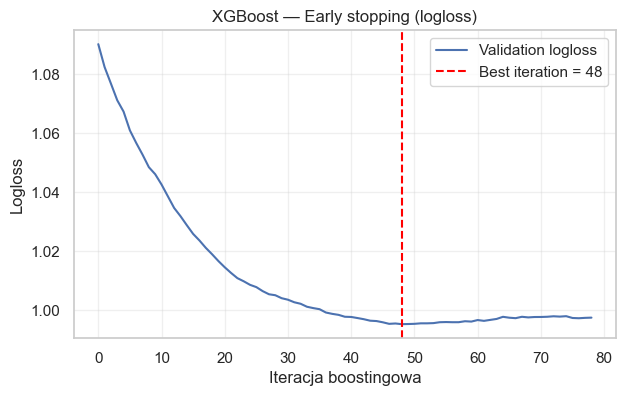

In [385]:
# ============================================
# EARLY STOPPING — KRZYWA UCZENIA (LOGLOSS)
# ============================================

evals_result = xgb_final.evals_result()

train_logloss = evals_result["validation_0"]["mlogloss"]

plt.figure(figsize=(7,4))
plt.plot(train_logloss, label="Validation logloss")
plt.axvline(
    xgb_final.best_iteration,
    color="red",
    linestyle="--",
    label=f"Best iteration = {xgb_final.best_iteration}"
)

plt.xlabel("Iteracja boostingowa")
plt.ylabel("Logloss")
plt.title("XGBoost — Early stopping (logloss)")
plt.legend()
plt.grid(alpha=0.3)

save_plot("xgboost_early_stopping_logloss.png")
plt.show()
close_plot()


In [386]:
y_pred = xgb_final.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred)
f1m_xgb = f1_score(y_test, y_pred, average="macro")

print("=== XGBoost (TEST) ===")
print("Accuracy:", acc_xgb)
print("Macro-F1:", f1m_xgb)
print(classification_report(y_test, y_pred, target_names=le_xgb.classes_))

acc_xgb_final = acc_xgb
f1m_xgb_final = f1m_xgb

=== XGBoost (TEST) ===
Accuracy: 0.5144736842105263
Macro-F1: 0.4780917044719555
              precision    recall  f1-score   support

           A       0.51      0.55      0.53       232
           D       0.26      0.29      0.27       169
           H       0.67      0.60      0.63       359

    accuracy                           0.51       760
   macro avg       0.48      0.48      0.48       760
weighted avg       0.53      0.51      0.52       760



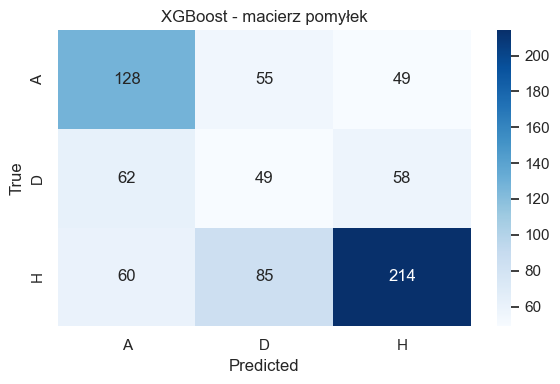

In [387]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_xgb.classes_,
            yticklabels=le_xgb.classes_)
plt.title("XGBoost - macierz pomyłek")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
save_plot("xgboost_confusion_matrix.png")
plt.show()
close_plot()


In [388]:
results_xgb = pd.DataFrame([{
    "Model": "XGBoost",
    "Accuracy": acc_xgb_final,
    "Macro-F1": f1m_xgb_final,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train),
    "N_test": len(y_test)
}])

save_df(results_xgb, "xgboost_results.csv")
display(results_xgb)


,Model,Accuracy,Macro-F1,League,SplitDate,N_train,N_test
0,XGBoost,0.514474,0.478092,premier_league,2022-07-01,2660,760


In [389]:

from sklearn.metrics import classification_report
report_xgb = classification_report(
    y_test,
    y_pred,
    target_names=le_xgb.classes_,
    output_dict=True
)


df_report_xgb = pd.DataFrame(report_xgb).T


df_report_xgb["Model"] = "XGBoost"
df_report_xgb["League"] = LEAGUE
df_report_xgb["SplitDate"] = split_date
df_report_xgb["N_train"] = len(y_train)
df_report_xgb["N_test"] = len(y_test)

# zapis do CSV
save_df(df_report_xgb, "xgboost_classification_report.csv")

display(df_report_xgb)


,precision,recall,f1-score,support,Model,League,SplitDate,N_train,N_test
A,0.512000,0.551724,0.531120,232.000000,XGBoost,premier_league,2022-07-01,2660,760
D,0.259259,0.289941,0.273743,169.000000,XGBoost,premier_league,2022-07-01,2660,760
H,0.666667,0.596100,0.629412,359.000000,XGBoost,premier_league,2022-07-01,2660,760
accuracy,0.514474,0.514474,0.514474,0.514474,XGBoost,premier_league,2022-07-01,2660,760
macro avg,0.479309,0.479255,0.478092,760.000000,XGBoost,premier_league,2022-07-01,2660,760
weighted avg,0.528858,0.514474,0.520318,760.000000,XGBoost,premier_league,2022-07-01,2660,760


C:\Users\tdroz\AppData\Local\Temp\ipykernel_6772\603690229.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


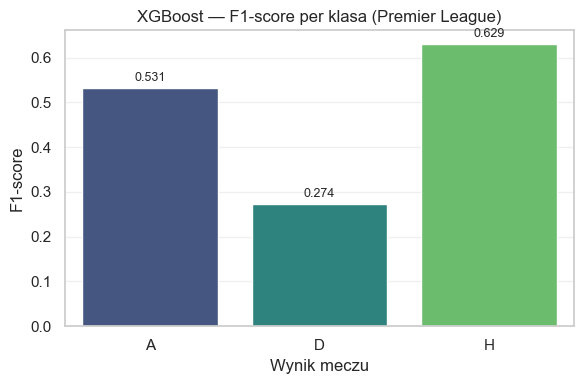

In [404]:
df_f1_class_xgb = (
    df_report_xgb
    .loc[le_xgb.classes_, ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class_xgb,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)

# wartości nad słupkami
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title("XGBoost — F1-score per klasa (Premier League)")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


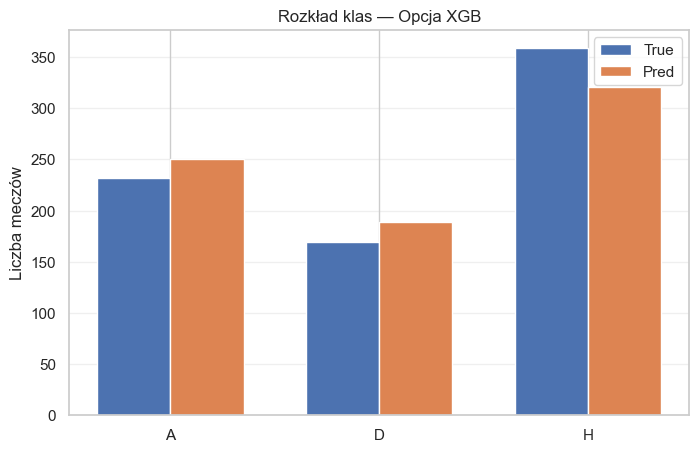

,Class,True_Count,Pred_Count
0,A,232,250
1,D,169,189
2,H,359,321


In [390]:
y_true_cls_xgb = le_xgb.inverse_transform(y_test)
y_pred_cls_xgb = le_xgb.inverse_transform(y_pred)

plot_and_save_class_distribution(
    y_true_cls_xgb,
    y_pred_cls_xgb,
    option_suffix="XGB",
    filename_prefix="class_distribution"
)


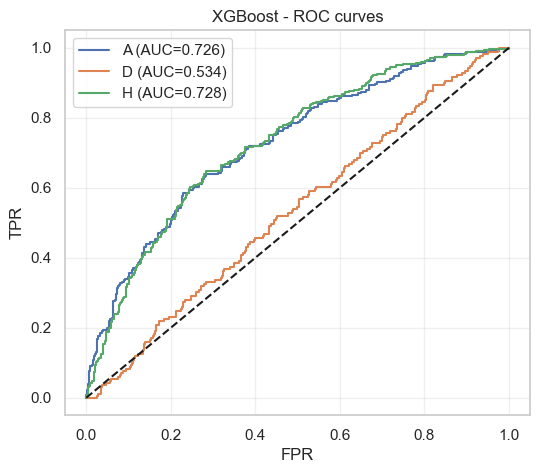

In [391]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(le_xgb.classes_)))
proba = xgb_final.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i, cls in enumerate(le_xgb.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("XGBoost - ROC curves")
plt.legend()
plt.grid(alpha=0.3)
save_plot("xgboost_roc_curves.png")
plt.show()
close_plot()

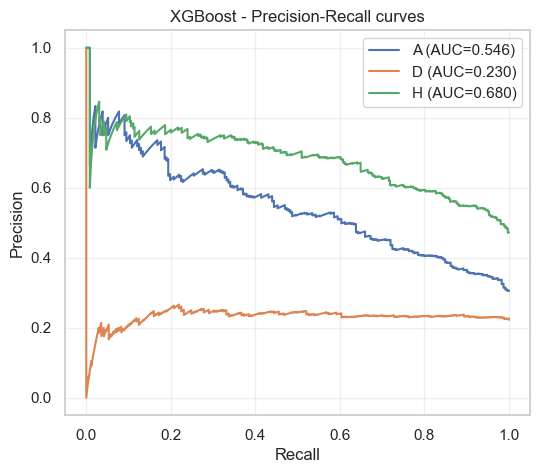

In [392]:
plt.figure(figsize=(6,5))

for i, cls in enumerate(le_xgb.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{cls} (AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost - Precision-Recall curves")
plt.legend()
plt.grid(alpha=0.3)
save_plot("xgboost_precision_recall.png")
plt.show()
close_plot()

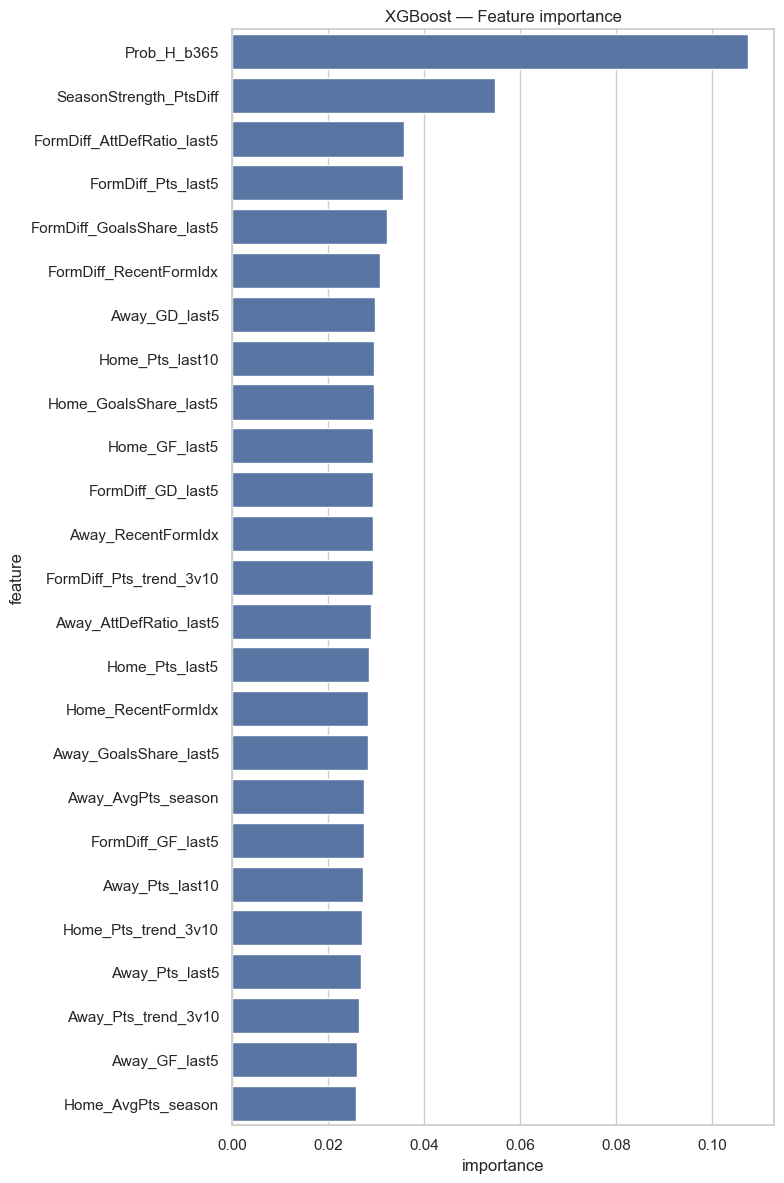

In [393]:
importances = xgb_final.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances,
    "Model": "XGBoost",
    "League": LEAGUE
}).sort_values("importance", ascending=False)

save_df(feat_imp, "xgboost_feature_importance.csv")

plt.figure(figsize=(8,12))
sns.barplot(data=feat_imp.head(25), x="importance", y="feature")
plt.title("XGBoost — Feature importance")
plt.tight_layout()

save_plot("xgboost_feature_importance.png")
plt.show()
close_plot()


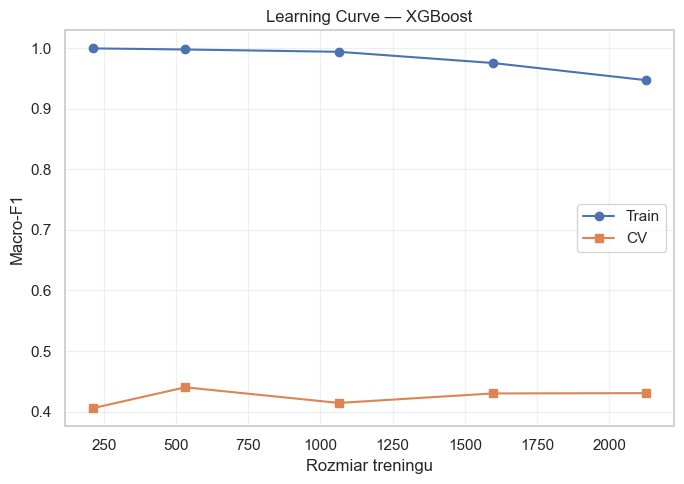

In [394]:
train_sizes, tr_scores, val_scores = learning_curve(
    best_xgb, X_train, y_train,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, tr_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "s-", label="CV")
plt.xlabel("Rozmiar treningu")
plt.ylabel("Macro-F1")
plt.title("Learning Curve — XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot("xgboost_learning_curve.png")
plt.show()
close_plot()


,Metric,Baseline_HomeWin,XGBoost,Gain_vs_Baseline
0,Accuracy,0.472368,0.514474,0.042105
1,Macro-F1,0.213881,0.478092,0.264210


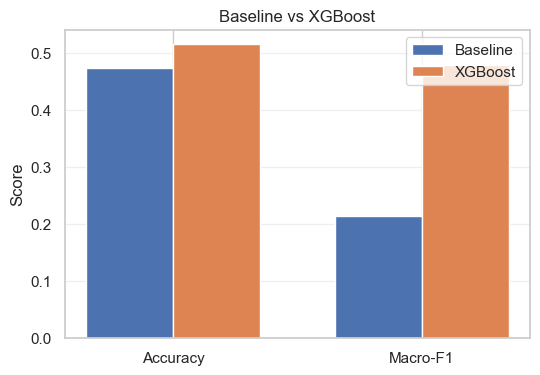

In [395]:
y_true_cls = y_true_cls_xgb.tolist()

# --- BASELINE ---
y_naive = ["H"] * len(y_true_cls)
acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")

# --- MODEL ---
acc_model = accuracy_score(y_true_cls, y_pred_cls_xgb)
f1_model  = f1_score(y_true_cls, y_pred_cls_xgb, average="macro")

df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "XGBoost": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

save_df(df_baseline_compare, "baseline_vs_xgboost.csv")
display(df_baseline_compare)

# --- wykres ---
plt.figure(figsize=(6,4))
x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive], width, label="Baseline")
plt.bar(x + width/2, [acc_model, f1_model], width, label="XGBoost")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs XGBoost")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_xgboost.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_6772\3809848849.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


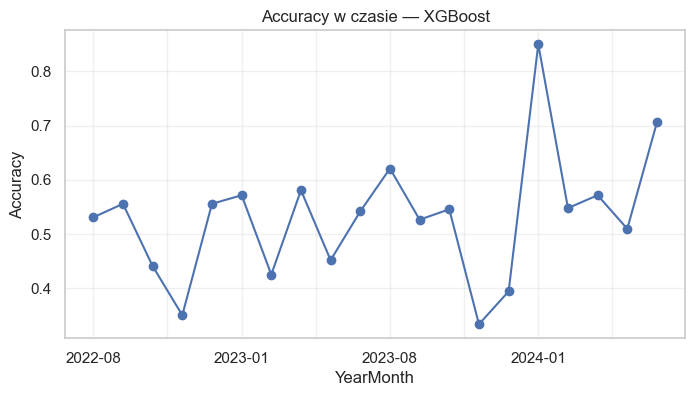

In [396]:
MIN_MATCHES = 10

df_eval_xgb = df.loc[test_mask, ["Date"]].copy()
df_eval_xgb["y_true"] = y_true_cls_xgb
df_eval_xgb["y_pred"] = y_pred_cls_xgb
df_eval_xgb["YearMonth"] = df_eval_xgb["Date"].dt.to_period("M").astype(str)

acc_per_month_xgb = (
    df_eval_xgb
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_xgboost = (
    acc_per_month_xgb
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_xgboost["Model"] = "XGBoost"

df_acc_xgboost.to_csv(
    RESULTS_DIR / "accuracy_per_month_xgboost.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_month_xgb.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy w czasie — XGBoost")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_xgboost.png")
plt.show()
close_plot()


<Figure size 600x500 with 0 Axes>

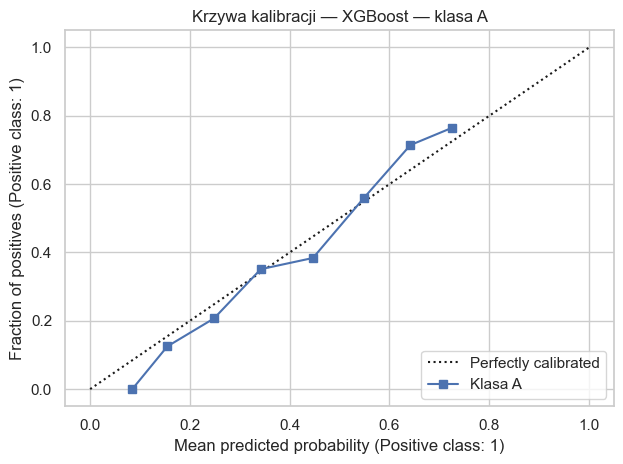

<Figure size 600x500 with 0 Axes>

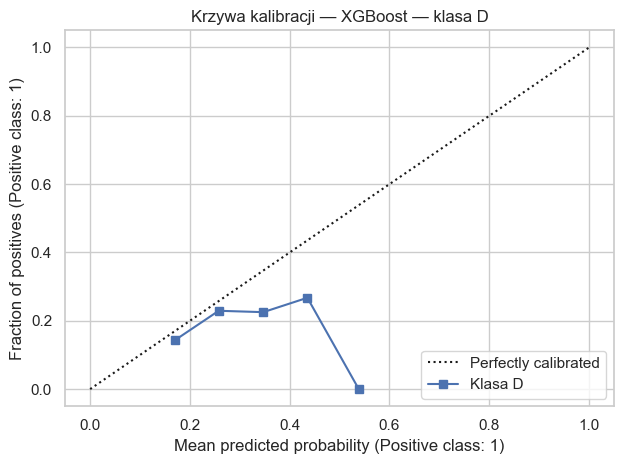

<Figure size 600x500 with 0 Axes>

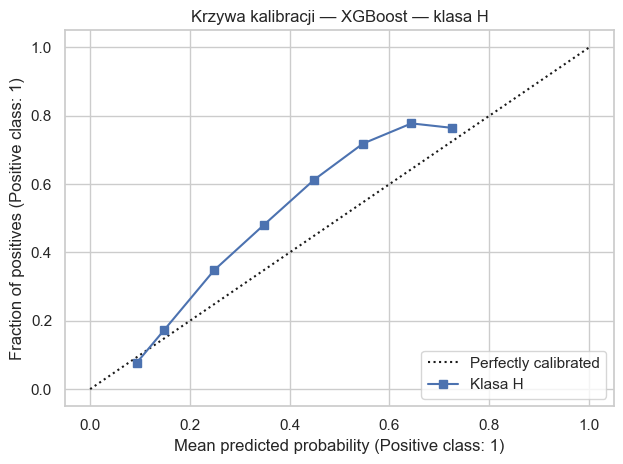

In [397]:
y_proba_xgb = xgb_final.predict_proba(X_test)

for i, cls in enumerate(le_xgb.classes_):
    plt.figure(figsize=(6,5))

    CalibrationDisplay.from_predictions(
        (y_test == i).astype(int),
        y_proba_xgb[:, i],
        n_bins=10,
        name=f"Klasa {cls}"
    )

    plt.title(f"Krzywa kalibracji — XGBoost — klasa {cls}")
    plt.tight_layout()

    save_plot(f"xgboost_calibration_{cls}.png")
    plt.show()
    close_plot()


<class 'numpy.ndarray'>
(760, 32, 3)


<Figure size 640x480 with 0 Axes>

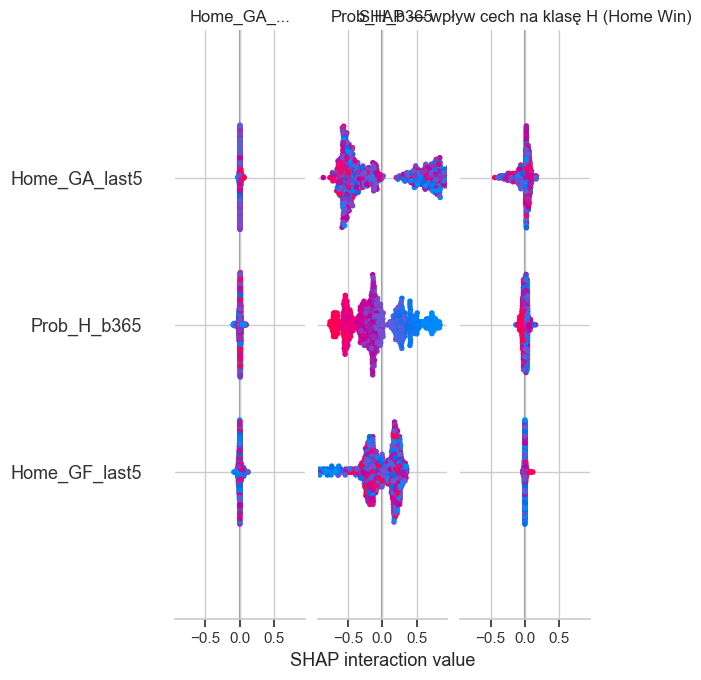

In [398]:
import shap

explainer = shap.TreeExplainer(xgb_final)


shap_values = explainer.shap_values(X_test)
idx_H = list(le_xgb.classes_).index("H")
print(type(shap_values))
print(np.array(shap_values).shape)
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)
plt.title("SHAP — wpływ cech na klasę H (Home Win)")
save_plot("xgboost_shap_summary_H.png")
plt.show()
close_plot()


shap_values shape: (760, 32, 3)
X_test shape: (760, 32)
Top feature: Prob_H_b365


<Figure size 640x480 with 0 Axes>

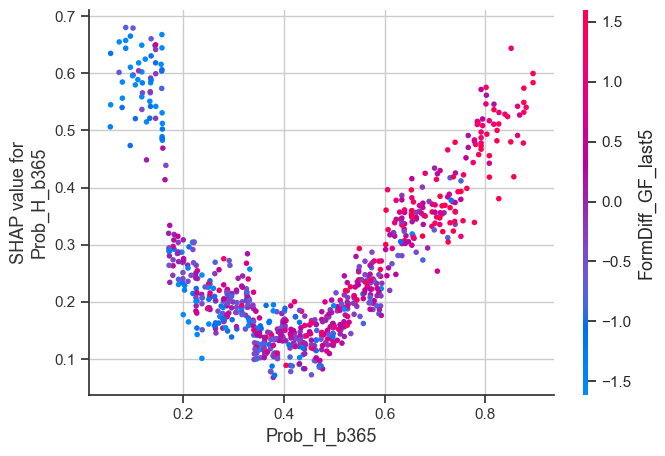

In [399]:
'''
print("shap_values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

assert shap_values.shape == X_test.shape, "SHAP i X_test muszą mieć ten sam shape"


top_feature = X_test.columns[
    np.abs(shap_values).mean(axis=0).argmax()
]

print("Top feature:", top_feature)


plt.figure()
shap.dependence_plot(
    top_feature,
    shap_values,  
    X_test,
    show=False
)

save_plot(f"xgboost_shap_dependence_{top_feature}.png")
plt.show()
close_plot()
# DLA PREMIER LEAGUE
'''


# ================================
# SHAP — multiclass dependence plot (FULL CELL)
# ================================

import numpy as np
import matplotlib.pyplot as plt
import shap

# Debug shapes
print("shap_values shape:", shap_values.shape)
print("X_test shape:", X_test.shape)

# --- Multiclass handling ---
# Uśrednienie SHAP po klasach → (n_samples, n_features)
shap_mean = np.abs(shap_values).mean(axis=2)

# Sprawdzenie poprawności
assert shap_mean.shape == X_test.shape, (
    f"Expected {X_test.shape}, got {shap_mean.shape}"
)

# --- Najważniejsza cecha globalnie ---
top_feature_idx = shap_mean.mean(axis=0).argmax()
top_feature = X_test.columns[top_feature_idx]

print("Top feature:", top_feature)

# --- Dependence plot ---
plt.figure()
shap.dependence_plot(
    top_feature,
    shap_mean,
    X_test,
    show=False
)

save_plot(f"xgboost_shap_dependence_{top_feature}.png")
plt.show()
close_plot()


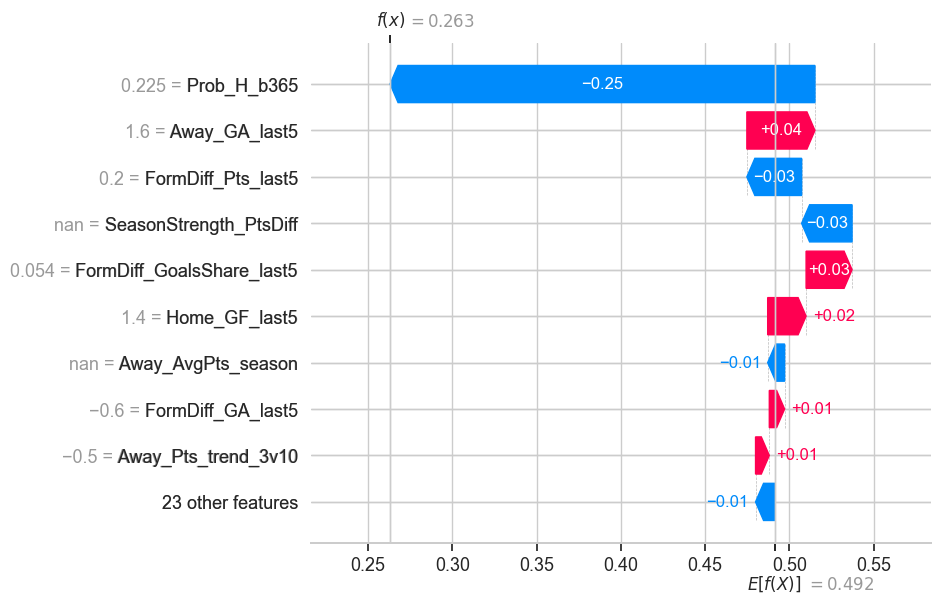

In [400]:
# ============================================
# SHAP — lokalne wyjaśnienie jednej obserwacji (klasa H)
# ============================================

idx = 0 
idx_H = list(le_xgb.classes_).index("H")


shap_exp = explainer(X_test.iloc[[idx]])


shap_exp_H = shap_exp[:, :, idx_H]

plt.figure()
shap.plots.waterfall(
    shap_exp_H[0],   
    show=False
)

save_plot(f"xgboost_shap_local_match_{idx}_H.png")
plt.show()
close_plot()


Model nie widzi tego meczu jako dobrego kandydata na Home Win,
głównie dlatego, że kursy bukmacherskie + forma punktowa silnie temu przeczą.